# Plant Disease Diagnosis — Unsupervised Domain Adaptation

CDAN+E, Mean Teacher (MT-only) và CDAN+E + Mean Teacher trên PlantVillage (lab) → PlantPathology (field).


## 1 — Setup, Installation & Reproducibility

In [ ]:
!pip install torch torchvision -q
!pip install segment-anything -q        # SAM for FBR segmentation
!pip install kaggle -q                  # Download PlantPathology dataset

import os, random, copy, warnings
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms as T
import torchvision.models as tv_models
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset, Subset
from sklearn.model_selection import train_test_split
from PIL import Image
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')


# ══════════════════════════════════════════════════════════════════════════════
# FULL REPRODUCIBILITY SETUP
# ══════════════════════════════════════════════════════════════════════════════
# Goal: identical results across different runs.
#
# Deep learning has MANY sources of randomness. To make runs reproducible,
# we must control ALL of them:
#   1. Python's random module        (data shuffling, sampling)
#   2. NumPy's random generator       (augmentation, array ops)
#   3. PyTorch CPU random             (weight init, dropout)
#   4. PyTorch GPU (CUDA) random      (GPU weight init, cuDNN ops)
#   5. cuDNN algorithm selection      (convolution backends)
#   6. DataLoader worker randomness   (parallel data loading)

def set_seed(seed: int = 42):
    """
    Set all random seeds for full reproducibility.

    Args:
        seed: The random seed value. Same seed → same results every run.
    """
    random.seed(seed)                            # Python built-in RNG
    np.random.seed(seed)                         # NumPy RNG
    torch.manual_seed(seed)                      # PyTorch CPU RNG
    torch.cuda.manual_seed(seed)                 # PyTorch current GPU RNG
    torch.cuda.manual_seed_all(seed)             # PyTorch all GPUs RNG

    # cuDNN determinism:
    #   deterministic=True  → use only deterministic algorithms (reproducible)
    #   benchmark=False     → disable auto-tuner that picks different algorithms
    #                         (the auto-tuner is faster but non-deterministic)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

    # Force PyTorch to raise an error if any operation is non-deterministic,
    # so we catch hidden sources of randomness. warn_only=True keeps training
    # running (some ops have no deterministic version) but warns us.
    torch.use_deterministic_algorithms(True, warn_only=True)

    # Required by some CUDA operations for full determinism.
    os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'


def seed_worker(worker_id: int):
    """
    Seed each DataLoader worker process for reproducibility.

    When num_workers > 0, each worker is a separate process with its own RNG.
    Without seeding, workers produce different augmentations each run.
    (We use num_workers=0 on Colab, but this is here for completeness.)

    Args:
        worker_id: Automatically passed by PyTorch to each worker.
    """
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


# Ensures DataLoader shuffling is reproducible.
g = torch.Generator()
g.manual_seed(42)

SEED = 42
set_seed(SEED)
print(f'\nReproducibility enabled (seed={SEED})')
print('  - All RNGs seeded (Python, NumPy, PyTorch CPU/GPU)')
print('  - cuDNN deterministic mode ON, benchmark OFF')
print('  - Deterministic algorithms enforced')
print('Setup complete.')


Device : cuda
GPU    : Tesla T4

Reproducibility enabled (seed=42)
  - All RNGs seeded (Python, NumPy, PyTorch CPU/GPU)
  - cuDNN deterministic mode ON, benchmark OFF
  - Deterministic algorithms enforced
Setup complete.


## 2 — Mount Google Drive & Configure Paths

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Root directory for all checkpoints, caches, and datasets.
SAVE_DIR = '/content/drive/MyDrive/GRAD PACKAGE/THESIS/PAPER RESEARCH/FBR UDA'
os.makedirs(SAVE_DIR, exist_ok=True)

# Dataset directories
PLANT_VILLAGE_SAVE_PATH   = os.path.join(SAVE_DIR, 'PlantVillage')
PLANT_PATHOLOGY_SAVE_PATH = os.path.join(SAVE_DIR, 'PlantPathology')
PLANT_VILLAGE_DIR         = os.path.join(PLANT_VILLAGE_SAVE_PATH, 'raw', 'color')
PLANT_PATHOLOGY_DIR       = PLANT_PATHOLOGY_SAVE_PATH

print(f'Checkpoint directory: {SAVE_DIR}')


Mounted at /content/drive
Checkpoint directory: /content/drive/MyDrive/GRAD PACKAGE/THESIS/PAPER RESEARCH/FBR UDA


## 3 — Download Datasets

### 3.1 — PlantVillage (PVD) — Source Domain (Lab Images)

Over 54,000 leaf images captured in controlled lab conditions with plain
backgrounds. We use only the 3 Apple classes that match PlantPathology.


In [ ]:
# ── Download PlantVillage from GitHub ─────────────────────────────────────────
os.makedirs(PLANT_VILLAGE_SAVE_PATH, exist_ok=True)
needs_download = (not os.path.exists(PLANT_VILLAGE_SAVE_PATH)
                  or not os.listdir(PLANT_VILLAGE_SAVE_PATH))

if needs_download:
    print('Downloading PlantVillage...')
    !git clone https://github.com/spMohanty/PlantVillage-Dataset.git "{PLANT_VILLAGE_SAVE_PATH}" --depth=1 -q
    print('PlantVillage download complete.')
else:
    print('PlantVillage already exists. Skipping download.')


PlantVillage already exists. Skipping download.


### 3.2 — PlantPathology (PPD) — Target Domain (Real Field Images)

Real apple leaf images from the Kaggle Plant Pathology 2020 competition,
captured in orchards with complex natural backgrounds. This is our target domain.

**Security note:** Upload your `kaggle.json` when prompted instead of hardcoding
the API token. Never commit API tokens to version control.


In [ ]:
import json
import os
import zipfile, glob

KAGGLE_API_TOKEN = 'KGAT_f145b2ef3e319f8898282f98be50beef'

# ── Setup Kaggle credentials ──────────────────────────────────────────────────
kaggle_dir = os.path.expanduser('~/.kaggle')
os.makedirs(kaggle_dir, exist_ok=True)

# ── Write to access_token file ────────────────────────────────────────────────
with open(os.path.join(kaggle_dir, 'access_token'), 'w') as f:
    f.write(KAGGLE_API_TOKEN)
!chmod 600 {kaggle_dir}/access_token

# ── Download PlantPathology ───────────────────────────────────────────────────
os.makedirs(PLANT_PATHOLOGY_SAVE_PATH, exist_ok=True)

is_download = not os.path.exists(os.path.join(PLANT_PATHOLOGY_SAVE_PATH, 'train.csv'))

if is_download:
    print('Downloading Plant Pathology 2020 - FGVC7 dataset from Kaggle...')
    !kaggle competitions download -c plant-pathology-2020-fgvc7 -p "{PLANT_PATHOLOGY_SAVE_PATH}"

    print('Unzipping...')
    for zip_file in glob.glob(os.path.join(PLANT_PATHOLOGY_SAVE_PATH, '*.zip')):
        with zipfile.ZipFile(zip_file, 'r') as z:
            z.extractall(PLANT_PATHOLOGY_SAVE_PATH)
        os.remove(zip_file)
    print('PlantPathology downloaded and unzipped!')
else:
    print('PlantPathology already exists. Skipping download.')

PlantPathology already exists. Skipping download.


### 3.3 — Transforms & Dataset Class

Two transforms:
- **TRAIN_TRANSFORM** — with augmentation (random crop, flips, color jitter) to
  prevent overfitting and simulate the visual variety of field conditions.
- **VAL_TRANSFORM** — deterministic (resize only) for consistent evaluation.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# TRANSFORMS
# ══════════════════════════════════════════════════════════════════════════════

TRAIN_TRANSFORM = T.Compose([
    T.Resize((256, 256)),      # Resize larger than target so RandomCrop has room
    T.RandomCrop(224),         # ResNet-18 needs 224x224; random crop = augmentation
    T.RandomHorizontalFlip(),  # Disease pattern is left-right invariant
    T.RandomVerticalFlip(),    # Disease pattern is up-down invariant
    T.ColorJitter(             # Simulate varied field lighting (lab has fixed light)
        brightness=0.2,
        contrast=0.2,
        saturation=0.1,
    ),
    T.ToTensor(),              # PIL (H,W,C)[0,255] -> tensor (C,H,W)[0,1]
    T.Normalize(               # Match ImageNet statistics (ResNet-18 was pretrained on it)
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225],
    ),
])

VAL_TRANSFORM = T.Compose([
    T.Resize((224, 224)),      # Direct resize, no crop — deterministic
    T.ToTensor(),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225],
    ),
])


# ══════════════════════════════════════════════════════════════════════════════
# DATASET CLASS
# ══════════════════════════════════════════════════════════════════════════════

class PlantDiseaseDataset(Dataset):
    """
    Unified dataset for both PVD (source) and PPD (target).

    Args:
        data_dir : Root folder where each subfolder is one class.
                   Used for auto-discovery mode. Mutually exclusive with `samples`.
        samples  : Pre-built list of (image_path, label_idx) tuples.
                   Used when we filter/sample images manually beforehand.
        classes  : List of class names, e.g. ["healthy", "rust", "scab"].
                   Required when using `samples`.
        transform: Torchvision transform pipeline applied to each image.
        labeled  : If True,  __getitem__ returns (image, label).
                   If False, __getitem__ returns (image, -1) for the unlabeled
                   target domain. This prevents accidental use of target labels
                   during UDA training.
    """

    def __init__(self, data_dir=None, samples=None, classes=None,
                 transform=None, labeled=True):
        self.transform = transform
        self.labeled   = labeled

        if data_dir is not None:
            # Auto-discover: each subfolder name is a class.
            self.classes      = sorted([
                d for d in os.listdir(data_dir)
                if os.path.isdir(os.path.join(data_dir, d))
            ])
            self.class_to_idx = {c: i for i, c in enumerate(self.classes)}
            self.samples      = []
            for cls in self.classes:
                cls_dir = os.path.join(data_dir, cls)
                for fname in os.listdir(cls_dir):
                    if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                        self.samples.append(
                            (os.path.join(cls_dir, fname), self.class_to_idx[cls])
                        )
        else:
            # Manual mode: use the provided samples list.
            self.samples      = samples
            self.classes      = classes
            self.class_to_idx = {c: i for i, c in enumerate(classes)}

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        # convert('RGB') handles grayscale/RGBA images → always 3 channels
        image = Image.open(path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return (image, label) if self.labeled else (image, -1)

    def get_labels(self):
        """Return all labels — required for StratifiedKFold class balancing."""
        return [s[1] for s in self.samples]

print('Transforms and dataset class defined.')


Transforms and dataset class defined.


### 3.4 — Load & Split Datasets

**Why the split ratios differ between PVD and PPD:**

| Dataset | Split | Reason |
|---|---|---|
| **PVD** (source, labeled) | 75% train / 25% val | Standard supervised split. Validation set is used for model selection. Paper: *"reserved 25% for validation"* |
| **PPD** (target, unlabeled) | 60% target / 40% test | No train/val split needed since we never use PPD labels for training. 60% provides unlabeled images for UDA alignment; 40% is held out for final evaluation only. |

Refactored into 5 clean functions below.


In [ ]:
import pandas as pd

# ── Configuration ─────────────────────────────────────────────────────────────
PVD_CLASS_MAP = {
    "Apple___healthy"          : 0,   # healthy
    "Apple___Cedar_apple_rust" : 1,   # rust
    "Apple___Apple_scab"       : 2,   # scab
}
CLASS_NAMES   = ["healthy", "rust", "scab"]
NUM_CLASSES   = len(CLASS_NAMES)
MAX_PER_CLASS = 300
VALID_EXTS    = (".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG")


def load_pvd_samples(data_dir, class_map=PVD_CLASS_MAP,
                     max_per_class=MAX_PER_CLASS, seed=SEED):
    """
    Load and filter PlantVillage source samples.

    Args:
        data_dir      : Path to PlantVillage/raw/color/ (subfolders per class).
        class_map     : Dict mapping folder name -> integer label.
        max_per_class : Max images to sample per class (paper uses ~275-300).
        seed          : Random seed for reproducible sampling.

    Returns:
        List of (image_path, label_idx) tuples.
    """
    random.seed(seed)   # reproducible shuffle
    samples = []
    print('[PVD] Loading source domain (lab images)...')

    for folder_name, label_idx in class_map.items():
        folder_path = os.path.join(data_dir, folder_name)
        # Fuzzy-match folder name across PlantVillage versions.
        if not os.path.isdir(folder_path):
            matches = [f for f in os.listdir(data_dir)
                       if folder_name.lower() in f.lower()]
            if matches:
                folder_path = os.path.join(data_dir, matches[0])
            else:
                print(f'  WARNING: class folder not found: {folder_name}')
                continue

        imgs = [os.path.join(folder_path, f)
                for f in os.listdir(folder_path) if f.endswith(VALID_EXTS)]
        random.shuffle(imgs)                     # shuffle before slicing
        selected = imgs[:max_per_class]
        samples.extend([(p, label_idx) for p in selected])
        print(f'  {folder_name:<28}: {len(imgs):>5} available -> {len(selected):>4} used')

    print(f'  Total PVD samples: {len(samples)}')
    return samples


def load_ppd_samples(data_dir, class_names=CLASS_NAMES):
    """
    Load PlantPathology target samples from train.csv.

    Keeps only single-label rows (healthy/rust/scab). Rows labeled
    'multiple_diseases' are skipped because PVD has no matching class.

    Args:
        data_dir    : Path to PlantPathology/ (contains train.csv and images/).
        class_names : Ordered class names matching the CSV column headers.

    Returns:
        List of (image_path, label_idx) tuples.
    """
    train_csv    = os.path.join(data_dir, "train.csv")
    img_dir      = os.path.join(data_dir, "images")
    class_to_idx = {c: i for i, c in enumerate(class_names)}
    samples      = []

    print('[PPD] Loading target domain (real field images)...')
    df = pd.read_csv(train_csv)

    for _, row in df.iterrows():
        img_path = os.path.join(img_dir, str(row["image_id"]) + ".jpg")
        if not os.path.exists(img_path):
            continue
        # 'break' after first match keeps single-label rows only.
        for cls in class_names:
            if row.get(cls, 0) == 1:
                samples.append((img_path, class_to_idx[cls]))
                break

    print(f'  Total PPD samples (single-label): {len(samples)}')
    return samples


def split_pvd(samples, val_ratio=0.25, seed=SEED):
    """
    Stratified 75/25 train/val split for the labeled source domain.

    Stratified means each class keeps the same proportion in both splits,
    which is important when classes are imbalanced.

    Args:
        samples   : List of (path, label) from load_pvd_samples().
        val_ratio : Fraction reserved for validation (paper: 0.25).
        seed      : Random seed for reproducible split.

    Returns:
        (train_set, val_set) as Subset objects.
        train_set uses TRAIN_TRANSFORM, val_set uses VAL_TRANSFORM.
    """
    labels  = [s[1] for s in samples]
    indices = list(range(len(samples)))
    train_idx, val_idx = train_test_split(
        indices, test_size=val_ratio, stratify=labels, random_state=seed
    )
    ds_train = PlantDiseaseDataset(samples=samples, classes=CLASS_NAMES,
                                   transform=TRAIN_TRANSFORM, labeled=True)
    ds_val   = PlantDiseaseDataset(samples=samples, classes=CLASS_NAMES,
                                   transform=VAL_TRANSFORM,   labeled=True)
    return Subset(ds_train, train_idx), Subset(ds_val, val_idx)


def split_ppd(samples, target_ratio=0.6, seed=SEED):
    """
    Random 60/40 split of the target domain.

    Args:
        samples      : List of (path, label) from load_ppd_samples().
        target_ratio : Fraction used as unlabeled UDA target (default 0.6).
        seed         : Random seed. CRITICAL — a fixed seed guarantees the
                       test set is identical every run, so accuracy numbers
                       are comparable across runs.

    Returns:
        (target_subset, test_subset)
        target_subset: unlabeled images for UDA alignment
        test_subset  : labeled images for final evaluation only
    """
    ds = PlantDiseaseDataset(samples=samples, classes=CLASS_NAMES,
                             transform=VAL_TRANSFORM, labeled=True)
    indices = list(range(len(samples)))
    random.seed(seed)                # fixed seed BEFORE shuffle
    random.shuffle(indices)
    n_target = int(len(indices) * target_ratio)
    return Subset(ds, indices[:n_target]), Subset(ds, indices[n_target:])


def make_loader(dataset, batch_size=64, shuffle=False, drop_last=False):
    """
    Create a reproducible, Colab-safe DataLoader.

    Args:
        dataset    : Dataset or Subset to wrap.
        batch_size : Samples per batch (paper: 64).
        shuffle    : True for training loaders, False for eval loaders.
        drop_last  : True for training/target loaders to keep batch sizes equal
                     (some UDA losses assume equal source/target batch sizes).

    Returns:
        DataLoader with num_workers=0 (stable on Colab) and a fixed generator
        (reproducible shuffling).
    """
    return DataLoader(
        dataset,
        batch_size     = batch_size,
        shuffle        = shuffle,
        num_workers    = 0,             # 0 avoids Colab worker crashes
        pin_memory     = True,
        drop_last      = drop_last,
        worker_init_fn = seed_worker,   # reproducible worker RNG
        generator      = g,             # reproducible shuffle order
    )


In [ ]:
# ── Load everything ───────────────────────────────────────────────────────────
set_seed(SEED)

pvd_samples = load_pvd_samples(PLANT_VILLAGE_DIR)
ppd_samples = load_ppd_samples(PLANT_PATHOLOGY_DIR)

# Full source dataset (used later for the FBR cache).
dataset_A = PlantDiseaseDataset(samples=pvd_samples, classes=CLASS_NAMES,
                                transform=TRAIN_TRANSFORM, labeled=True)

# PVD 75/25 split
train_set_A, val_set_A = split_pvd(pvd_samples, val_ratio=0.25, seed=SEED)

# PPD 60/40 split
dataset_B_target, dataset_B_test = split_ppd(ppd_samples, target_ratio=0.6, seed=SEED)

# DataLoaders
train_loader_A = make_loader(train_set_A,      batch_size=64, shuffle=True,  drop_last=True)
val_loader_A   = make_loader(val_set_A,        batch_size=64, shuffle=False)
target_loader  = make_loader(dataset_B_target, batch_size=64, shuffle=True,  drop_last=True)
test_loader_B  = make_loader(dataset_B_test,   batch_size=64, shuffle=False)

print(f'\n{"="*55}')
print('DATA SUMMARY')
print(f'{"="*55}')
print(f'  PVD train (75%) : {len(train_set_A):>5} samples  (labeled)')
print(f'  PVD val   (25%) : {len(val_set_A):>5} samples  (labeled)')
print(f'  PPD target (60%): {len(dataset_B_target):>5} samples  (unlabeled)')
print(f'  PPD test   (40%): {len(dataset_B_test):>5} samples  (labeled)')
print(f'{"="*55}')


[PVD] Loading source domain (lab images)...
  Apple___healthy             :  1645 available ->  300 used
  Apple___Cedar_apple_rust    :   275 available ->  275 used
  Apple___Apple_scab          :   630 available ->  300 used
  Total PVD samples: 875
[PPD] Loading target domain (real field images)...
  Total PPD samples (single-label): 1730

DATA SUMMARY
  PVD train (75%) :   656 samples  (labeled)
  PVD val   (25%) :   219 samples  (labeled)
  PPD target (60%):  1038 samples  (unlabeled)
  PPD test   (40%):   692 samples  (labeled)


## 4 — FBR: Field-adaptive Background Recomposition

**Idea:** Use SAM to segment the leaf out of the plain lab background, then
composite it onto a real field background from PPD. This makes lab images
visually resemble field images, reducing the domain gap before UDA.

**Three steps per image:**
1. `segment_leaf` — SAM with a center-point prompt (leaves are always centered in PVD)
2. `refine_mask` — morphological cleanup (fill holes, smooth edges)
3. `composite` — alpha-blend leaf onto a random field background


In [ ]:
import cv2

# ── Download and load SAM ─────────────────────────────────────────────────────
SAM_CHECKPOINT = '/content/sam_vit_b_01ec64.pth'
SAM_MODEL_TYPE = 'vit_b'   # vit_b (~375MB) is sufficient for centered leaves

if not os.path.exists(SAM_CHECKPOINT):
    print('Downloading SAM checkpoint (vit_b, ~375MB)...')
    !wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth -O {SAM_CHECKPOINT}
    print('SAM checkpoint downloaded.')

from segment_anything import sam_model_registry, SamPredictor
sam      = sam_model_registry[SAM_MODEL_TYPE](checkpoint=SAM_CHECKPOINT).to(DEVICE)
sam_pred = SamPredictor(sam)
print(f'SAM loaded on {DEVICE}.')


SAM checkpoint downloaded.
SAM loaded on cuda.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# FBR CORE FUNCTIONS
# ══════════════════════════════════════════════════════════════════════════════

def segment_leaf(predictor, image_rgb):
    """
    Segment the leaf using SAM with a single center-point prompt.

    Args:
        predictor : SamPredictor with the image already loadable.
        image_rgb : (H, W, 3) uint8 RGB image.

    Returns:
        (H, W) boolean mask — True where the leaf is.
    """
    h, w = image_rgb.shape[:2]
    predictor.set_image(image_rgb)
    masks, scores, _ = predictor.predict(
        point_coords     = np.array([[w // 2, h // 2]]),  # center pixel
        point_labels     = np.array([1]),                 # 1 = foreground
        multimask_output = True,                          # return 3 candidates
    )
    return masks[np.argmax(scores)]   # pick highest-confidence mask


def refine_mask(mask, k_d=15, k_e=10, k_g=5, iterations=2):
    """
    Clean up the raw SAM mask with morphological operations.

    Args:
        mask       : (H, W) boolean mask from SAM.
        k_d        : Dilation kernel size (fills holes, merges fragments).
        k_e        : Erosion kernel size (removes boundary noise). Must be < k_d.
        k_g        : Gaussian blur kernel size (odd) for soft edges.
        iterations : Times to repeat dilation+erosion.

    Returns:
        (H, W) float32 soft mask in [0, 1] used as the alpha channel.

    Paper hyperparameters: k_d=15, k_e=10, k_g=5, iterations=2.
    """
    m  = mask.astype(np.uint8) * 255
    kd = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k_d, k_d))
    ke = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k_e, k_e))
    for _ in range(iterations):
        m = cv2.dilate(m, kd)   # expand: fill holes
        m = cv2.erode(m,  ke)   # shrink: clean edges (k_e < k_d = net expand)
    m = cv2.GaussianBlur(m, (k_g, k_g), 0)   # soft edges for natural blending
    return m.astype(np.float32) / 255.0


def composite(lab_img, mask, bg_img):
    """
    Alpha-composite the leaf onto a field background.

    output = mask * leaf + (1 - mask) * background

    Args:
        lab_img : (H, W, 3) uint8 lab image.
        mask    : (H, W) float32 soft mask in [0, 1].
        bg_img  : (H, W, 3) uint8 field background.

    Returns:
        (H, W, 3) uint8 composited image.
    """
    h, w  = lab_img.shape[:2]
    bg    = cv2.resize(bg_img, (w, h))
    alpha = mask[:, :, np.newaxis]                      # (H, W, 1) for broadcast
    out   = alpha * lab_img.astype(np.float32) + (1 - alpha) * bg.astype(np.float32)
    return np.clip(out, 0, 255).astype(np.uint8)


def random_field_background(bg_path, out_w, out_h):
    """
    Build a field background patch the way the paper describes:
    random crop -> random rotation -> center crop (removes black corners).

    Args:
        bg_path      : Path to an unlabeled real-field image.
        out_w, out_h : Output size (matches the lab image).

    Returns:
        (out_h, out_w, 3) uint8 RGB background patch at close-up scale.
    """
    img  = cv2.cvtColor(cv2.imread(bg_path), cv2.COLOR_BGR2RGB)
    H, W = img.shape[:2]

    # 1) Random square patch, 30-70% of the short side.
    #    KEY FIX: take a PATCH of field texture, not the whole scene resized
    #    down (which would drag another PPD leaf into the background).
    s = int(random.uniform(0.30, 0.70) * min(H, W))
    x = random.randint(0, W - s)
    y = random.randint(0, H - s)
    patch = img[y:y + s, x:x + s]

    # 2) Random rotation (creates black corners — removed in step 3)
    M = cv2.getRotationMatrix2D((s / 2, s / 2), random.uniform(0, 360), 1.0)
    patch = cv2.warpAffine(patch, M, (s, s))

    # 3) Center-crop by 1/sqrt(2): largest square guaranteed to sit inside
    #    the rotated area, so no black corners survive.
    c = int(s / np.sqrt(2))
    o = (s - c) // 2
    patch = patch[o:o + c, o:o + c]

    # 4) Scale to the lab image size
    return cv2.resize(patch, (out_w, out_h))


def fbr_single(lab_path, bg_paths, predictor):
    """
    Full FBR pipeline for one lab image.

    Args:
        lab_path  : Path to the source lab image.
        bg_paths  : List of field background paths (one chosen at random).
        predictor : SamPredictor.

    Returns:
        (H, W, 3) uint8 composited image (leaf on field background).
    """
    lab_rgb = cv2.cvtColor(cv2.imread(lab_path), cv2.COLOR_BGR2RGB)
    h, w    = lab_rgb.shape[:2]

    refined_mask = refine_mask(segment_leaf(predictor, lab_rgb))
    bg_rgb       = random_field_background(random.choice(bg_paths), w, h)

    return composite(lab_rgb, refined_mask, bg_rgb)

print('FBR functions defined.')


FBR functions defined.


### 4.1 — Pre-compute FBR Cache

**Why pre-cache instead of running SAM on-the-fly?**
Running SAM inside the DataLoader would (a) be ~100x slower and (b) produce a
different mask each epoch, making training non-deterministic and unstable.
We run SAM once, save the results as JPEG, then load them like any image.

**Background source:** only the PPD **target split** (not the test set) — using
test-set backgrounds would leak test information into training.


In [ ]:
import shutil

FBR_CACHE_DIR = os.path.join(SAVE_DIR, 'fbr_cache')

# The old cache was built with the buggy background (whole image resized,
# black corners). Delete it so every image is regenerated with the fix.
# if os.path.exists(FBR_CACHE_DIR):
#     shutil.rmtree(FBR_CACHE_DIR)
#     print('[reset] cleared old FBR cache')
# os.makedirs(FBR_CACHE_DIR, exist_ok=True)

# Background images from the TARGET split only (avoids test-set leakage).
fbr_bg_paths = [dataset_B_target.dataset.samples[i][0] for i in dataset_B_target.indices] \
    if hasattr(dataset_B_target, 'indices') else \
    [s[0] for s in ppd_samples]

# Fallback: if the above is empty, use all PPD images folder.
if not fbr_bg_paths:
    img_folder = os.path.join(PLANT_PATHOLOGY_DIR, 'images')
    fbr_bg_paths = [os.path.join(img_folder, f) for f in os.listdir(img_folder)
                    if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

print(f'Background images (target split): {len(fbr_bg_paths)}')
print(f'Pre-computing FBR for {len(pvd_samples)} source images...')

set_seed(SEED)   # reproducible background selection + rotation
fbr_cached_samples = []
n_new = n_skip = 0

for idx, (orig_path, label) in enumerate(tqdm(pvd_samples)):
    cache_path = os.path.join(FBR_CACHE_DIR, f'{idx:05d}_c{label}.jpg')
    if not os.path.exists(cache_path):
        try:
            result = fbr_single(orig_path, fbr_bg_paths, sam_pred)
            Image.fromarray(result).save(cache_path, quality=92)
            n_new += 1
        except Exception:
            shutil.copy(orig_path, cache_path)   # fallback to original
            n_new += 1
    else:
        n_skip += 1
    fbr_cached_samples.append((cache_path, label))

print(f'\nFBR cache complete. Computed: {n_new} | Reused: {n_skip}')
print(f'Cache directory: {FBR_CACHE_DIR}')


Background images (target split): 1038
Pre-computing FBR for 875 source images...


  0%|          | 0/875 [00:00<?, ?it/s]


FBR cache complete. Computed: 0 | Reused: 875
Cache directory: /content/drive/MyDrive/GRAD PACKAGE/THESIS/PAPER RESEARCH/FBR UDA/fbr_cache


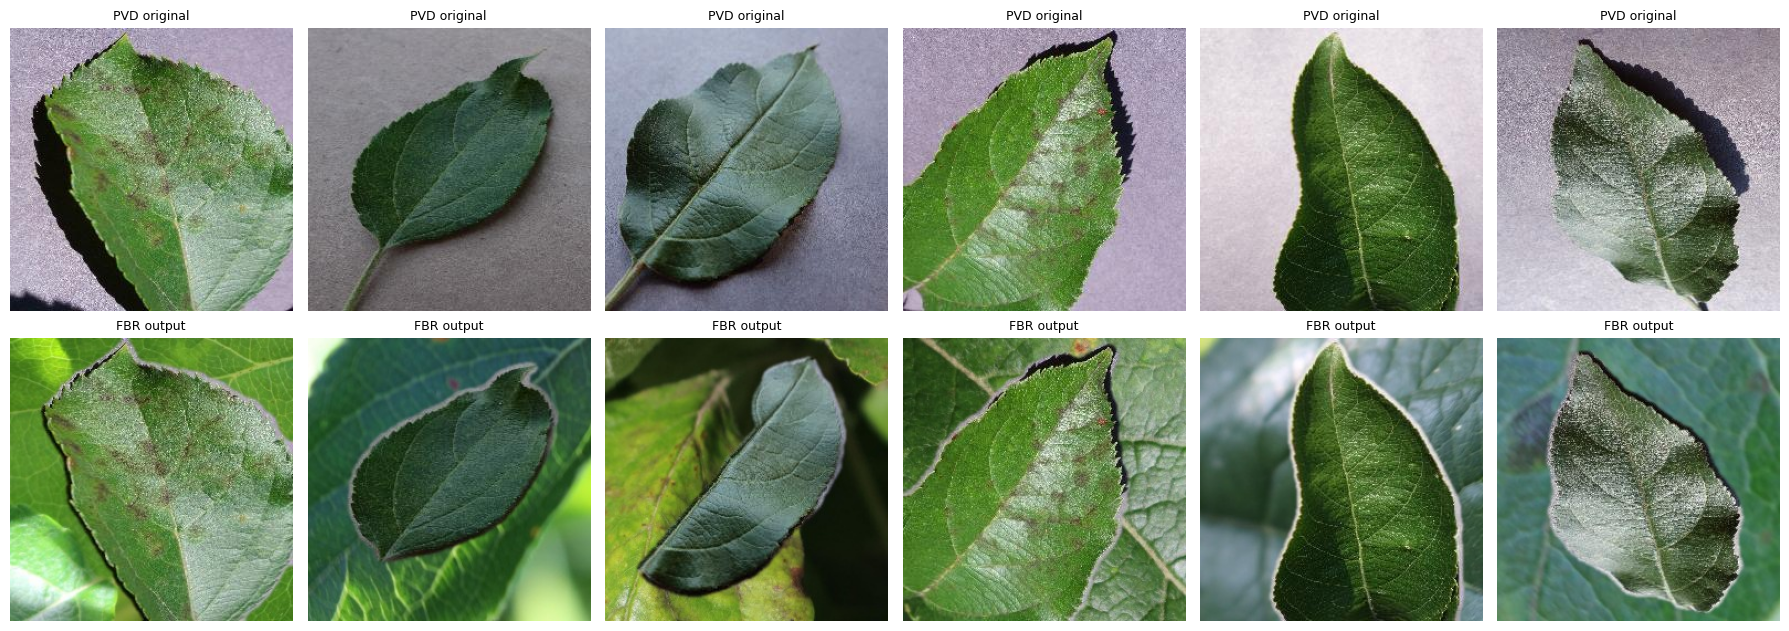

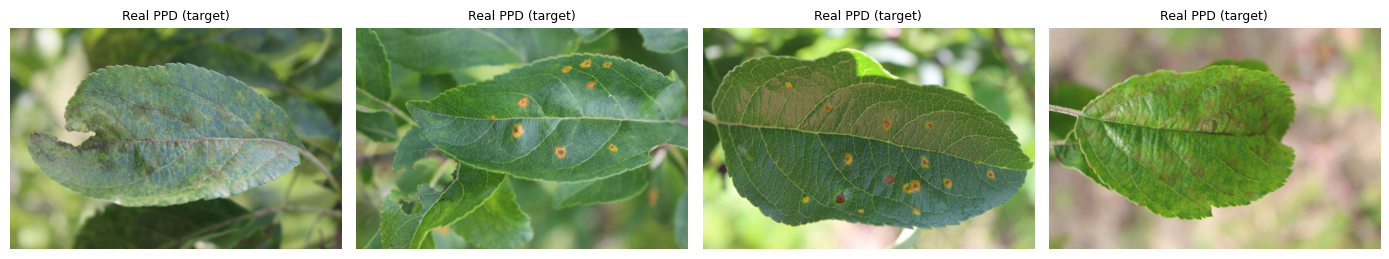

In [ ]:
# ── Visual sanity check: do the FBR images look like real field photos? ──
import matplotlib.pyplot as plt

n    = 6
idxs = random.sample(range(len(fbr_cached_samples)), n)

fig, axes = plt.subplots(2, n, figsize=(3*n, 6.5))
for j, idx in enumerate(idxs):
    axes[0, j].imshow(Image.open(pvd_samples[idx][0]).convert('RGB'))
    axes[0, j].set_title('PVD original', fontsize=9); axes[0, j].axis('off')
    axes[1, j].imshow(Image.open(fbr_cached_samples[idx][0]).convert('RGB'))
    axes[1, j].set_title('FBR output', fontsize=9); axes[1, j].axis('off')
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for j, p in enumerate(random.sample(fbr_bg_paths, 4)):
    axes[j].imshow(Image.open(p).convert('RGB'))
    axes[j].set_title('Real PPD (target)', fontsize=9); axes[j].axis('off')
plt.tight_layout(); plt.show()

In [ ]:
# ── Build FBR train/val loaders from cache ────────────────────────────────────
# Both train AND val use FBR images for consistent model selection.
dataset_A_fbr = PlantDiseaseDataset(samples=fbr_cached_samples, classes=CLASS_NAMES,
                                    transform=TRAIN_TRANSFORM, labeled=True)

fbr_labels = dataset_A_fbr.get_labels()
fbr_tr_idx, fbr_vl_idx = train_test_split(
    list(range(len(dataset_A_fbr))), test_size=0.25,
    stratify=fbr_labels, random_state=SEED
)

train_loader_A_fbr = make_loader(Subset(dataset_A_fbr, fbr_tr_idx), 64, shuffle=True, drop_last=True)
val_loader_A_fbr   = make_loader(Subset(dataset_A_fbr, fbr_vl_idx), 64, shuffle=False)

print(f'FBR loaders ready: train={len(fbr_tr_idx)} | val={len(fbr_vl_idx)}')


FBR loaders ready: train=656 | val=219


## 5 — Unsupervised Domain Adaptation: CDAN+E

Ba nhánh, dùng chung một pipeline dữ liệu:

| Nhánh | Loss | Mục đích |
|---|---|---|
| **CDAN+E** | `L_cls + L_cdan` | Alignment đối kháng có điều kiện theo lớp (multilinear map + entropy weighting) |
| **MT-only** *(mới, 5.5)* | `L_cls + w(t)·L_cons` | Chỉ consistency regularization trên target, **không** có discriminator/GRL |
| **CDAN+E + Mean Teacher** | `L_cls + L_cdan + w(t)·L_cons` | Cộng thêm consistency regularization trên target không nhãn |

Cả hai đều dùng chung ResNet-18 làm feature extractor và train trên:
- **FBR-augmented source** (có nhãn) cho classification
- **PPD target** (không nhãn) cho domain alignment

Mọi cell dưới đây lưu checkpoint mỗi 10 epoch và resume được sau khi Colab ngắt.


### 5.1 — GRL & Model Architectures

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# LAMBDA SCHEDULE & DOMAIN LABELS
# ══════════════════════════════════════════════════════════════════════════════

def get_lambda(step, max_steps, gamma=10.0):
    """
    Progressive GRL lambda schedule (DANN).
    Increases from ~0 to ~1 over training so classification is learned first.

    Args:
        step     : Current iteration index.
        max_steps: Total iterations (epochs * batches_per_epoch).
        gamma    : Growth rate (paper: 10.0).
    Returns:
        Lambda value in [0, 1).
    """
    p = step / max_steps
    return 2.0 / (1.0 + torch.exp(torch.tensor(-gamma * p)).item()) - 1.0


def domain_lbl(n, is_src, device):
    """Domain labels: source=0, target=1. Returns (n,) long tensor."""
    return torch.full((n,), 0 if is_src else 1, dtype=torch.long, device=device)


# ══════════════════════════════════════════════════════════════════════════════
# GRADIENT REVERSAL LAYER
# ══════════════════════════════════════════════════════════════════════════════

class GRL(torch.autograd.Function):
    """
    Gradient Reversal Layer autograd function.
    Forward:  identity. Backward: multiply gradient by -lambda.
    This is what turns a normal discriminator into an adversarial one.
    """
    @staticmethod
    def forward(ctx, x, lam):
        ctx.save_for_backward(torch.tensor(lam))
        return x.clone()
    @staticmethod
    def backward(ctx, grad):
        return -ctx.saved_tensors[0].item() * grad, None   # reversed gradient


class GradRevLayer(nn.Module):
    """nn.Module wrapper around GRL with an adjustable lambda."""
    def __init__(self, lam=1.0):
        super().__init__()
        self.lam = lam
    def forward(self, x):
        return GRL.apply(x, self.lam)
    def set_lam(self, lam):
        self.lam = lam


# ══════════════════════════════════════════════════════════════════════════════
# MODEL ARCHITECTURES
# ══════════════════════════════════════════════════════════════════════════════

class FeatureExtractor(nn.Module):
    """ResNet backbone with the final FC layer removed.

    backbone='resnet18' (default, paper 10 / all main results): output 512-dim.
    backbone='resnet50' (ablation only, see 5.7): output 2048-dim. Changes
    out_dim, so a resnet50 run is NOT interchangeable with a resnet18 run's
    checkpoints or state_dicts.
    """
    def __init__(self, pretrained=True, backbone='resnet18'):
        super().__init__()
        if backbone == 'resnet18':
            weights = tv_models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
            net = tv_models.resnet18(weights=weights)
            self.out_dim = 512
        elif backbone == 'resnet50':
            weights = tv_models.ResNet50_Weights.IMAGENET1K_V2 if pretrained else None
            net = tv_models.resnet50(weights=weights)
            self.out_dim = 2048
        else:
            raise ValueError(f'unknown backbone: {backbone}')
        self.backbone = backbone
        self.net = nn.Sequential(*list(net.children())[:-1])
    def forward(self, x):
        return self.net(x).flatten(1)   # (N, out_dim)


class Classifier(nn.Module):
    """Linear label classifier G: 512 -> num_classes."""
    def __init__(self, in_dim=512, num_classes=3):
        super().__init__()
        self.fc = nn.Linear(in_dim, num_classes)
    def forward(self, x):
        return self.fc(x)


class CDANDisc(nn.Module):
    """
    Conditional domain discriminator for CDAN+E.
    Input is the multilinear map (features x predictions), dim = 512*num_classes.
    Two hidden layers (512, 256).
    """
    def __init__(self, in_dim=512, num_classes=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim * num_classes, 512), nn.ReLU(),
            nn.Linear(512, 256), nn.ReLU(),
            nn.Linear(256, 2)
        )
    def forward(self, x):
        return self.net(x)


def multilinear_map(feat, pred):
    """
    Outer product features x predictions for CDAN+E conditioning.

    Args:
        feat: (N, d) features. pred: (N, C) softmax predictions.
    Returns:
        (N, d*C) flattened outer product.
    NOTE: do NOT detach feat/pred here — gradients must flow through GRL to phi.
    """
    N = feat.size(0)
    return torch.bmm(feat.unsqueeze(2), pred.unsqueeze(1)).view(N, -1)


def uda_test(phi, G, loader, device):
    """
    Evaluate a UDA model (feature extractor phi + classifier G).

    Args:
        phi   : Feature extractor.
        G     : Label classifier.
        loader: Test DataLoader.
        device: 'cuda' or 'cpu'.
    Returns:
        Accuracy (float).
    """
    phi.eval(); G.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            correct += (G(phi(imgs)).argmax(1) == lbls).sum().item()
            total   += lbls.size(0)
    return correct / total

print('GRL, CDAN+E models and helpers defined.')


GRL, CDAN+E models and helpers defined.


### 5.2 — Checkpoint Helper & Results Store

The checkpoint helper is shared by the single-run CDAN+E cell below; the
Mean Teacher branch has its own variant that also stores teacher state.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CHECKPOINT HELPERS (dung cho cell CDAN+E don-seed)
# ══════════════════════════════════════════════════════════════════════════════

def save_uda_checkpoint(path, epoch, step, best_loss, best_state,
                        phi, G, optimizer, scheduler, D=None):
    """
    Save a full UDA training checkpoint so training can resume after a restart.

    Args:
        path      : File path to write the checkpoint to.
        epoch     : Last completed epoch.
        step      : Global iteration counter (keeps lambda schedule continuous).
        best_loss : Best validation loss seen so far.
        best_state: dict {'phi','G'} of the best model weights.
        phi, G    : Current feature extractor and classifier.
        optimizer : Optimizer (includes Adam momentum buffers).
        scheduler : LR scheduler (includes cosine schedule position).
        D         : CDAN+E conditional discriminator.
    """
    ckpt = {
        'epoch': epoch, 'step': step,
        'best_loss': best_loss, 'best_state': best_state,
        'phi': phi.state_dict(), 'G': G.state_dict(),
        'optimizer': optimizer.state_dict(),
        'scheduler': scheduler.state_dict(),
    }
    if D is not None:
        ckpt['D'] = D.state_dict()
    torch.save(ckpt, path)


def load_uda_checkpoint(path, phi, G, optimizer, scheduler, D=None, device='cpu'):
    """
    Load a UDA checkpoint if it exists.

    Args:
        path      : Checkpoint file path.
        phi, G    : Models to restore weights into.
        optimizer : Optimizer to restore.
        scheduler : Scheduler to restore.
        D         : Optional discriminator to restore.
        device    : Map location.

    Returns:
        (start_epoch, step, best_loss, best_state) to continue training,
        or (1, 0, inf, None) if no checkpoint exists.
    """
    if not os.path.exists(path):
        return 1, 0, float('inf'), None
    ckpt = torch.load(path, map_location=device)
    phi.load_state_dict(ckpt['phi'])
    G.load_state_dict(ckpt['G'])
    optimizer.load_state_dict(ckpt['optimizer'])
    scheduler.load_state_dict(ckpt['scheduler'])
    if D is not None and 'D' in ckpt:
        D.load_state_dict(ckpt['D'])
    print(f'[Resume] Loaded checkpoint at epoch {ckpt["epoch"]} -> continuing from {ckpt["epoch"]+1}')
    return ckpt['epoch'] + 1, ckpt['step'], ckpt['best_loss'], ckpt['best_state']


# Reference results from the paper (Apple, genuine setting).
# Baseline (ResNet-18 on PVD, no adaptation) measured in an earlier full run of
# this notebook. Kept as a hardcoded reference so the no-adaptation training
# section is not needed just to print a delta.
acc_on_B = 0.6040

paper_results = {'CDAN+E w/ FBR': 91.1}

# Store all results as we go.
all_results = {'Baseline (ref)': acc_on_B * 100}
print('Checkpoint helpers ready. Results store initialized.')


Checkpoint helpers ready. Results store initialized.


### 5.3 — CDAN+E (Conditional Domain Adversarial Network + Entropy)

**Đây là baseline.** Section 5.4 bên dưới chạy đúng cấu hình này cộng thêm Mean
Teacher, cùng `SEED`, để đo riêng phần đóng góp của MT.

Improves DANN in two ways:
1. **Conditional**: the discriminator sees features conditioned on predictions
   (multilinear map), enabling class-specific alignment.
2. **Entropy weighting (+E)**: confident samples contribute more to the domain
   loss, giving a cleaner adversarial signal.

**Critical:** the multilinear map must NOT detach the features, otherwise
gradients cannot flow back through the GRL and adversarial training silently
fails (accuracy collapses to ~48%).

#### (1) Vì sao phải thêm `g.manual_seed`

`set_seed()` seed Python/NumPy/PyTorch nhưng **không đụng tới `g`** — generator
riêng mà `make_loader` dùng để shuffle. `g` chỉ được seed một lần ở cell 2 rồi
cứ chạy tiếp qua mọi loader, mọi epoch. Hệ quả: chạy cell này lần thứ hai trong
cùng phiên sẽ cho thứ tự dữ liệu khác lần đầu, và ra kết quả khác — dù `SEED`
không đổi.

Vì vậy cell này re-seed `g` theo từng epoch (`SEED * 1000 + epoch`). Vừa làm
cell tái lập được, vừa khiến resume từ checkpoint tiếp đúng thứ tự dữ liệu của
epoch đó thay vì một thứ tự tuỳ ý. Cell 5.4 làm y hệt, nên hai cell thấy cùng
một chuỗi batch.


In [ ]:
set_seed(SEED)
g.manual_seed(SEED)          # xem ghi chu (1) o markdown 5.3
print('='*55)
print('METHOD: CDAN+E w/ FBR')
print('='*55)

ce = nn.CrossEntropyLoss()

MAX_EPOCHS_CDANE = 300
MIN_SEL_CDANE    = 250
CDANE_CKPT       = os.path.join(SAVE_DIR, 'cdane_checkpoint.pth')
CDANE_BEST       = os.path.join(SAVE_DIR, 'cdane_fbr.pth')

# Entropy-weighting formula changed (see below) -> retrain fresh from epoch 1.
for _p in (CDANE_CKPT, CDANE_BEST):
    if os.path.exists(_p):
        os.remove(_p)
        print(f'[reset] removed stale checkpoint: {os.path.basename(_p)}')

phi_ce = FeatureExtractor(pretrained=True).to(DEVICE)
G_ce   = Classifier(phi_ce.out_dim, NUM_CLASSES).to(DEVICE)
grl_ce = GradRevLayer().to(DEVICE)
D_ce   = CDANDisc(phi_ce.out_dim, NUM_CLASSES).to(DEVICE)

opt_ce = optim.AdamW(
    list(phi_ce.parameters()) + list(G_ce.parameters()) + list(D_ce.parameters()),
    lr=1e-3, weight_decay=0.01
)
sch_ce    = optim.lr_scheduler.CosineAnnealingLR(opt_ce, T_max=MAX_EPOCHS_CDANE)
ce_persam = nn.CrossEntropyLoss(reduction='none')


def cdan_entropy_weight(probs):
    """Official CDAN+E weight: w = 1 + exp(-H(p)). Confident -> ~2, uncertain -> ~1.
    Every sample contributes (min ~1); confident ones are emphasized. Detached
    so it acts as a coefficient, not a gradient path."""
    ent = -(probs * torch.log(probs + 1e-5)).sum(dim=1)   # per-sample entropy H(p)
    return (1.0 + torch.exp(-ent)).detach()


start_epoch, step, best_loss_ce, best_state_ce = load_uda_checkpoint(
    CDANE_CKPT, phi_ce, G_ce, opt_ce, sch_ce, D=D_ce, device=DEVICE
)
total_steps = MAX_EPOCHS_CDANE * min(len(train_loader_A_fbr), len(target_loader))

for epoch in range(start_epoch, MAX_EPOCHS_CDANE + 1):
    # Re-seed generator cua DataLoader theo epoch. Khong co dong nay thi thu tu
    # shuffle phu thuoc vao viec cell nay chay thu may trong phien, nen chay lai
    # cung SEED van ra ket qua khac, va resume tu checkpoint cung lech thu tu.
    g.manual_seed(SEED * 1000 + epoch)

    phi_ce.train(); G_ce.train(); D_ce.train()

    for (si, sl), (ti, _) in zip(train_loader_A_fbr, target_loader):
        si, sl, ti = si.to(DEVICE), sl.to(DEVICE), ti.to(DEVICE)
        lam = get_lambda(step, total_steps); grl_ce.set_lam(lam); step += 1
        opt_ce.zero_grad()

        sf = phi_ce(si); tf = phi_ce(ti)
        logits_s = G_ce(sf)
        sp = torch.softmax(logits_s, dim=1)
        tp = torch.softmax(G_ce(tf), dim=1)
        cls_loss = ce(logits_s, sl)

        # Multilinear map through GRL.
        # Detach the PREDICTIONS (official CDAN) but keep FEATURE gradient,
        # so the adversarial signal still reaches phi through the GRL.
        src_mm = grl_ce(multilinear_map(sf, sp.detach()))
        tgt_mm = grl_ce(multilinear_map(tf, tp.detach()))

        # Entropy weights (+E), official formula, normalized per domain (sum=1).
        sw = cdan_entropy_weight(sp); sw = sw / sw.sum()
        tw = cdan_entropy_weight(tp); tw = tw / tw.sum()

        src_d = (sw * ce_persam(D_ce(src_mm), domain_lbl(si.size(0), True,  DEVICE))).sum()
        tgt_d = (tw * ce_persam(D_ce(tgt_mm), domain_lbl(ti.size(0), False, DEVICE))).sum()
        dom_loss = (src_d + tgt_d) / 2.0

        (cls_loss + dom_loss).backward(); opt_ce.step()
    sch_ce.step()

    phi_ce.eval(); G_ce.eval()
    vl, vc, vt = 0.0, 0, 0
    with torch.no_grad():
        for vi, vlab in val_loader_A_fbr:
            vi, vlab = vi.to(DEVICE), vlab.to(DEVICE)
            logits = G_ce(phi_ce(vi))
            vl += ce(logits, vlab).item()
            vc += (logits.argmax(1) == vlab).sum().item()
            vt += vlab.size(0)
    val_loss, val_acc = vl / len(val_loader_A_fbr), vc / vt

    if epoch >= MIN_SEL_CDANE and val_loss < best_loss_ce:
        best_loss_ce  = val_loss
        best_state_ce = {'phi': copy.deepcopy(phi_ce.state_dict()),
                         'G':   copy.deepcopy(G_ce.state_dict())}
        torch.save(best_state_ce, CDANE_BEST)

    if epoch % 10 == 0:
        save_uda_checkpoint(CDANE_CKPT, epoch, step, best_loss_ce, best_state_ce,
                            phi_ce, G_ce, opt_ce, sch_ce, D=D_ce)
        print(f'  Epoch [{epoch:03d}/{MAX_EPOCHS_CDANE}] val_acc={val_acc*100:.1f}% '
              f'lam={lam:.3f} [ckpt saved]')

if best_state_ce is None:
    print('WARNING: model selection window not reached; using final weights.')
    best_state_ce = {'phi': phi_ce.state_dict(), 'G': G_ce.state_dict()}

phi_ce.load_state_dict(best_state_ce['phi'])
G_ce.load_state_dict(best_state_ce['G'])
cdane_acc = uda_test(phi_ce, G_ce, test_loader_B, DEVICE)
all_results['CDAN+E w/ FBR'] = cdane_acc * 100

print(f'\n[CDAN+E] Test PPD: {cdane_acc*100:.2f}%  (paper: 91.1%)  '
      f'vs Baseline: {(cdane_acc*100 - acc_on_B*100):+.2f}%')

METHOD: CDAN+E w/ FBR
[reset] removed stale checkpoint: cdane_checkpoint.pth
[reset] removed stale checkpoint: cdane_fbr.pth
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 195MB/s]


  Epoch [010/300] val_acc=97.7% lam=0.164 [ckpt saved]
  Epoch [020/300] val_acc=83.6% lam=0.320 [ckpt saved]
  Epoch [030/300] val_acc=96.3% lam=0.461 [ckpt saved]
  Epoch [040/300] val_acc=98.2% lam=0.582 [ckpt saved]
  Epoch [050/300] val_acc=95.9% lam=0.681 [ckpt saved]
  Epoch [060/300] val_acc=95.9% lam=0.761 [ckpt saved]
  Epoch [070/300] val_acc=95.9% lam=0.823 [ckpt saved]
  Epoch [080/300] val_acc=97.3% lam=0.870 [ckpt saved]
  Epoch [090/300] val_acc=94.5% lam=0.905 [ckpt saved]
  Epoch [100/300] val_acc=95.9% lam=0.931 [ckpt saved]
  Epoch [110/300] val_acc=97.3% lam=0.950 [ckpt saved]
  Epoch [120/300] val_acc=98.2% lam=0.964 [ckpt saved]
  Epoch [130/300] val_acc=96.8% lam=0.974 [ckpt saved]
  Epoch [140/300] val_acc=96.8% lam=0.981 [ckpt saved]
  Epoch [150/300] val_acc=96.8% lam=0.987 [ckpt saved]
  Epoch [160/300] val_acc=96.3% lam=0.990 [ckpt saved]
  Epoch [170/300] val_acc=96.3% lam=0.993 [ckpt saved]
  Epoch [180/300] val_acc=96.8% lam=0.995 [ckpt saved]
  Epoch [1

### 5.4 — CDAN+E + Mean Teacher

Cộng Mean Teacher (consistency regularization trên target không nhãn) lên đúng
cấu hình CDAN+E của cell 5.3, theo tinh thần *French et al., "Self-Ensembling
for Visual Domain Adaptation", ICLR 2018*.

```
L = L_cls + L_cdan + w(t) · L_cons
```

#### Thiết kế: một seed, hai cell, một biến

| | Cell 5.3 | Cell 5.4 |
|---|---|---|
| Input nhánh CDAN+E | ảnh target, VAL_TRANSFORM | **y hệt** (`t_plain`) |
| Loss | `L_cls + L_cdan` | `L_cls + L_cdan + w(t)·L_cons` |
| Input của `L_cons` | — | 2 view augment, forward riêng |
| Chọn model | student, val_loss, epoch ≥ 250 | teacher (EMA), **cùng tiêu chí** |
| Seed | `SEED` | `SEED` |

Ảnh augment **không** đi vào nhánh CDAN. Nhánh CDAN của 5.4 là bản sao nguyên
văn của 5.3, nên chênh lệch accuracy quy được về đúng `L_cons`.

#### Bốn thứ giữ cho hai cell thấy cùng dòng RNG

Cùng `SEED` là chưa đủ — `SEED` chỉ khống chế khởi tạo trọng số. Xem chi tiết
trong cell `train_cdane`; tóm tắt:

1. **Thứ tự khởi tạo** `FeatureExtractor → Classifier → CDANDisc` giống 5.3.
2. **`create_teacher` bọc trong `fork_rng`** — nó gọi thêm 2 module, không fork
   thì mọi augmentation ảnh source sau đó lệch pha.
3. **`g.manual_seed(SEED*1000 + epoch)`** mỗi epoch ở *cả hai* cell. `set_seed()`
   không đụng tới `g`, nên nếu thiếu dòng này thì ngay cả 5.3 chạy hai lần cũng
   ra hai kết quả khác nhau.
4. **`TargetThreeViewDataset` sinh view trong `fork_rng`**, seed theo
   `(SEED, epoch, idx)` — view đổi theo epoch, vẫn tái lập được sau resume, và
   không tiêu thụ RNG toàn cục.

Cell `rng_probe` đo trực tiếp bất biến này (~1 phút, không huấn luyện). Chạy nó
trước; `[FAIL]` nghĩa là phép so sánh đã hỏng, đừng chạy 300 epoch.

#### Hai chi tiết lấy từ source gốc, không suy ra được từ paper

1. `losses.py` của `milsever/plant-pathology` **không** detach teacher logits — repo
   chặn gradient bằng `freeze_all()` lúc khởi tạo. Ở đây ta làm cả hai:
   `requires_grad_(False)` và `torch.no_grad()`.
2. `update_ema_variables` của `CuriousAI/mean-teacher` chỉ duyệt `.parameters()`,
   **không** đụng buffer BatchNorm. Official bù lại bằng cách để teacher ở
   `.train()` mode suốt quá trình huấn luyện, nên BN running stats tự cập nhật.
   ResNet-18 có 20 lớp BN — để nhầm `.eval()` là teacher hỏng hoàn toàn.

`w(t)` ramp **trễ** (epoch 100 → 150) chứ không ramp sớm như paper SSL, vì ở đây
λ_GRL cũng đang ramp; ép consistency lúc feature còn xáo trộn mạnh dễ gây
confirmation bias.

#### Giới hạn phải nêu trong luận văn

Một seed thì **không có thanh sai số**. Chênh lệch giữa hai cell là chênh lệch
của một lần bốc mẫu, không phải một hiệu ứng đã được đo. Paper báo CDAN+E là
91.1 ± 4.22% — độ lệch chuẩn 4.22 điểm cho thấy phương sai theo seed ở setting
này rất lớn, nên một delta vài điểm hoàn toàn có thể là nhiễu seed.

Thiết kế ở đây bù lại bằng cách **triệt tiêu mọi nguồn khác biệt trừ `L_cons`**:
cùng khởi tạo, cùng thứ tự dữ liệu, cùng augmentation source. Đó là bằng chứng
mạnh hơn hai run độc lập, nhưng vẫn là n=1 — hãy phát biểu kết quả là "trên
seed này, MT thay đổi accuracy X điểm", đừng phát biểu là "MT cải thiện X điểm".


In [ ]:
# === CELL-TAG: mt_helpers ===
# ══════════════════════════════════════════════════════════════════════════════
# MEAN TEACHER — hằng số, lịch ramp, loss, EMA
# Nguồn: github.com/CuriousAI/mean-teacher và github.com/milsever/plant-pathology
# ══════════════════════════════════════════════════════════════════════════════

EMA_DECAY     = 0.99   # paper Ilsever & Baz, lấy từ test "4000 labels/ResNet CIFAR-10"
CONS_MAX      = 9.0    # = C^2; paper chọn consistency weight trong [C, C^2], C=3
CONS_START    = 100    # epoch bắt đầu ramp (sau khi lambda_GRL đã gần bão hoà)
CONS_RAMP_LEN = 50     # số epoch để ramp tới CONS_MAX


def sigmoid_rampup(x, length):
    """Sigmoid ramp-up của Laine & Aila (ramps.py gốc).

    Args:
        x     : Số epoch đã trôi qua kể từ lúc bắt đầu ramp.
        length: Số epoch để đạt bão hoà. 0 nghĩa là không ramp.
    Returns:
        Hệ số trong (0, 1]. Tại x=0 trả về exp(-5) ~ 0.0067, không phải 0.
    """
    if length == 0:
        return 1.0
    x = float(np.clip(x, 0.0, length)) / length
    return float(np.exp(-5.0 * (1.0 - x) ** 2))


def consistency_weight(epoch, cons_max=CONS_MAX, start=CONS_START,
                       ramp_len=CONS_RAMP_LEN):
    """Trọng số w(t) của consistency loss. Đúng 0 trước `start`."""
    if epoch < start:
        return 0.0
    return cons_max * sigmoid_rampup(epoch - start, ramp_len)


def softmax_mse_loss(input_logits, target_logits):
    """MSE giữa hai phân phối softmax. Sao chép nguyên văn losses.py của repo gốc.

    Trả về TỔNG trên toàn batch (chia num_classes). Chỗ gọi phải chia batch_size,
    đúng như ft_meanteacher.py làm.
    """
    assert input_logits.size() == target_logits.size()
    input_softmax  = F.softmax(input_logits,  dim=1)
    target_softmax = F.softmax(target_logits, dim=1)
    num_classes    = input_logits.size()[1]
    return F.mse_loss(input_softmax, target_softmax, reduction='sum') / num_classes


def cdan_entropy_weight(probs):
    """Trọng số entropy của CDAN+E: w = 1 + exp(-H(p)).

    Sao chép nguyên văn định nghĩa trong cell 5.3 (CDAN+E). Cố ý lặp lại ở đây
    để section 5.4 chạy được mà KHÔNG phải chạy cell đó — nó là một run 300 epoch
    đầy đủ. Hai định nghĩa giống hệt nhau nên kết quả không đổi dù chạy thứ tự nào.

    Tin cậy (H thấp) -> ~2, mơ hồ -> ~1. Detach để làm hệ số, không phải đường
    truyền gradient.
    """
    ent = -(probs * torch.log(probs + 1e-5)).sum(dim=1)
    return (1.0 + torch.exp(-ent)).detach()


def create_teacher(student_phi, student_G, num_classes, device, backbone='resnet18'):
    """Dựng teacher khởi tạo giống hệt student và đã khoá gradient.

    pretrained=False để khỏi tải lại weight ImageNet — trọng số bị ghi đè ngay
    bằng state_dict của student. backbone phải khớp với student_phi (xem 5.7).

    Returns:
        (phi_t, G_t) — cả hai đã requires_grad_(False).
    """
    phi_t = FeatureExtractor(pretrained=False, backbone=backbone).to(device)
    G_t   = Classifier(phi_t.out_dim, num_classes).to(device)
    phi_t.load_state_dict(student_phi.state_dict())
    G_t.load_state_dict(student_G.state_dict())
    for p in list(phi_t.parameters()) + list(G_t.parameters()):
        p.requires_grad_(False)
    return phi_t, G_t


def update_ema(student_mods, teacher_mods, global_step, ema_decay=EMA_DECAY):
    """Cập nhật EMA. Sao chép update_ema_variables của CuriousAI/mean-teacher.

    Dùng true average cho tới khi exponential average đủ chính xác, nên alpha
    tăng dần từ 0 lên `ema_decay`.

    LƯU Ý: chỉ duyệt .parameters(), KHÔNG đụng buffer BatchNorm. Buffer của
    teacher được cập nhật nhờ chính forward pass của nó ở .train() mode.

    Returns:
        alpha đã dùng (để log).
    """
    alpha = min(1 - 1 / (global_step + 1), ema_decay)
    with torch.no_grad():
        for sm, tm in zip(student_mods, teacher_mods):
            for ema_p, p in zip(tm.parameters(), sm.parameters()):
                ema_p.data.mul_(alpha).add_(p.data, alpha=1 - alpha)
    return alpha


print('Mean Teacher helpers defined.')

Mean Teacher helpers defined.


In [ ]:
# === CELL-TAG: target_3view_ds ===
# ══════════════════════════════════════════════════════════════════════════════
# DATASET TARGET 3 ĐẦU RA — (plain, view1, view2)
#
# ĐÂY LÀ CHỖ QUYẾT ĐỊNH PHÉP SO SÁNH VỚI CELL 5.3 CÓ HỢP LỆ HAY KHÔNG.
#
# plain = VAL_TRANSFORM, tất định — ĐÚNG ảnh mà cell 5.3 đưa vào nhánh CDAN+E.
# view1/view2 = TRAIN_TRANSFORM, hai lần bốc mẫu độc lập — CHỈ dùng cho L_cons.
#
# ── Vì sao phải fork_rng ─────────────────────────────────────────────────────
# TRAIN_TRANSFORM (RandomCrop/Flip/ColorJitter) bốc số từ RNG TOÀN CỤC của
# PyTorch — đúng cái RNG mà augmentation của ảnh source cũng đang dùng. Vòng lặp
# là zip(train_loader_A_fbr, target_loader_3v), nên hai bên bốc xen kẽ nhau.
#
# Cell 5.3 KHÔNG bốc gì cho target (VAL_TRANSFORM tất định). Nếu ở đây ta bốc
# thêm 2 view mỗi ảnh mà không cô lập, thì từ batch thứ hai trở đi ảnh SOURCE
# của cell 5.4 đã khác ảnh source của cell 5.3 — cùng SEED cũng vô nghĩa, và
# chênh lệch accuracy không còn quy được về Mean Teacher.
#
# torch.random.fork_rng lưu lại state toàn cục, cho phép ta seed riêng cho phần
# augmentation, rồi trả state về nguyên vẹn. Dòng RNG mà ảnh source nhìn thấy vì
# thế giống hệt cell 5.3, từng bước một.
#
# ── Vì sao seed của view phụ thuộc (seed, epoch, idx) ────────────────────────
# Chỉ theo idx thì mọi epoch dùng lại đúng hai view cũ -> mất hết đa dạng
# augmentation. Có epoch thì mỗi epoch một cặp view mới, nhưng vẫn tái lập được,
# kể cả sau khi resume giữa chừng (khác với bộ đếm nội bộ, thứ sẽ reset về 0).
# ══════════════════════════════════════════════════════════════════════════════

class TargetThreeViewDataset(Dataset):
    """Target không nhãn, trả ((plain, view1, view2), -1).

    Args:
        samples        : List (path, label). Label bị vứt — luôn trả -1 để chặn
                         rò rỉ nhãn target vào quá trình huấn luyện UDA.
        plain_transform: Tất định (VAL_TRANSFORM). Ảnh cho nhánh CDAN+E.
        aug_transform  : Ngẫu nhiên (TRAIN_TRANSFORM). Hai view cho L_cons.
        base_seed      : Seed gốc; cùng base_seed + epoch -> cùng bộ view.
    """

    def __init__(self, samples, plain_transform, aug_transform, base_seed):
        self.samples         = samples
        self.plain_transform = plain_transform
        self.aug_transform   = aug_transform
        self.base_seed       = base_seed
        self.epoch           = 0

    def set_epoch(self, epoch):
        """Vòng lặp huấn luyện PHẢI gọi mỗi epoch, nếu không 300 epoch dùng
        chung đúng một cặp view và Mean Teacher gần như không học được gì."""
        self.epoch = epoch

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, _ = self.samples[idx]
        img = Image.open(path).convert('RGB')

        # Ngoài fork: dùng RNG toàn cục, nhưng VAL_TRANSFORM không bốc số nào.
        plain = self.plain_transform(img)

        # Trong fork: state toàn cục được cất đi rồi trả lại y nguyên.
        # devices=[] để khỏi fork luôn RNG của CUDA (chậm và không cần).
        with torch.random.fork_rng(devices=[]):
            torch.manual_seed(
                (self.base_seed * 1_000_003 + self.epoch * 10_007 + idx) % (2**31 - 1)
            )
            v1 = self.aug_transform(img)
            v2 = self.aug_transform(img)

        return (plain, v1, v2), -1


print('TargetThreeViewDataset defined.')


TargetThreeViewDataset defined.


In [ ]:
# === CELL-TAG: target_3view_loader ===
# ══════════════════════════════════════════════════════════════════════════════
# LOADER TARGET 3 VIEW
#
# batch_size/shuffle/drop_last giống hệt `target_loader` của cell 5.3, nên
# steps_per_epoch bằng nhau -> lịch lambda_GRL của hai cell trùng khít.
# ══════════════════════════════════════════════════════════════════════════════

# dataset_B_target là một Subset; lấy lại danh sách (path, label) gốc của nó.
_target_samples = [
    dataset_B_target.dataset.samples[i] for i in dataset_B_target.indices
]

dataset_B_target_3v = TargetThreeViewDataset(
    samples         = _target_samples,
    plain_transform = VAL_TRANSFORM,
    aug_transform   = TRAIN_TRANSFORM,
    base_seed       = SEED,
)

target_loader_3v = make_loader(
    dataset_B_target_3v, batch_size=64, shuffle=True, drop_last=True
)

assert len(target_loader_3v) == len(target_loader), (
    f'so batch lech voi cell 5.3: {len(target_loader_3v)} vs {len(target_loader)} '
    '-> lich lambda_GRL se khac nhau'
)

# ── Kiểm tra tại chỗ ─────────────────────────────────────────────────────────
(_plain, _v1, _v2), _lbl = next(iter(target_loader_3v))
assert _plain.shape == _v1.shape == _v2.shape == (64, 3, 224, 224), f'sai shape: {_plain.shape}'
assert not torch.allclose(_v1, _v2), \
    'view1 == view2 -> L_cons se luon = 0. Kiem tra TRAIN_TRANSFORM.'
assert not torch.allclose(_plain, _v1), \
    'plain == view1 -> plain dang bi augment. Kiem tra VAL_TRANSFORM.'
assert (_lbl == -1).all(), 'Target loader dang tra ve nhan that.'

# ── Kiểm tra fork_rng thật sự không đụng vào RNG toàn cục ───────────────────
# Đây là bất biến mà toàn bộ phép so sánh với cell 5.3 dựa vào, nên phải test.
torch.manual_seed(123)
_before = torch.rand(3)
torch.manual_seed(123)
dataset_B_target_3v.set_epoch(7)
_ = dataset_B_target_3v[0]          # sinh plain + 2 view augment
_after = torch.rand(3)
assert torch.equal(_before, _after), (
    'fork_rng bi ro ri: augmentation dang lam lech RNG toan cuc. '
    'Anh source cua cell 5.4 se khac cell 5.3.'
)

# ── Kiểm tra view đổi theo epoch và tái lập được ────────────────────────────
dataset_B_target_3v.set_epoch(1); (_, _e1a, _) = dataset_B_target_3v[0][0]
dataset_B_target_3v.set_epoch(2); (_, _e2,  _) = dataset_B_target_3v[0][0]
dataset_B_target_3v.set_epoch(1); (_, _e1b, _) = dataset_B_target_3v[0][0]
assert not torch.allclose(_e1a, _e2), 'view khong doi theo epoch -> mat da dang augment'
assert torch.allclose(_e1a, _e1b),    'cung epoch ma view khac nhau -> khong tai lap duoc'

print(f'Target 3-view loader ready: {len(dataset_B_target_3v)} anh, '
      f'{len(target_loader_3v)} batch/epoch (khop cell 5.3)')
print(f'  plain vs view1 : mean|.| = {(_plain - _v1).abs().mean():.4f}')
print(f'  view1 vs view2 : mean|.| = {(_v1 - _v2).abs().mean():.4f}')
print('  fork_rng khong ro ri sang RNG toan cuc  [OK]')
print('  view doi theo epoch, cung epoch thi tai lap  [OK]')
del _plain, _v1, _v2, _lbl, _before, _after, _e1a, _e1b, _e2


Target 3-view loader ready: 1038 anh, 16 batch/epoch (khop cell 5.3)
  plain vs view1 : mean|.| = 0.7471
  view1 vs view2 : mean|.| = 0.7391
  fork_rng khong ro ri sang RNG toan cuc  [OK]
  view doi theo epoch, cung epoch thi tai lap  [OK]


In [ ]:
# === CELL-TAG: mt_checkpoint ===
# ══════════════════════════════════════════════════════════════════════════════
# CHECKPOINT cho nhánh CDAN+E (+MT)
#
# Không sửa save_uda_checkpoint/load_uda_checkpoint của section 5.2 — cell CDAN+E
# một-seed vẫn đang dùng chúng. Đây là cặp riêng, có thêm state của teacher.
#
# 10 run x 300 epoch trên Colab chắc chắn sẽ bị ngắt session giữa chừng, nên
# resume là bắt buộc chứ không phải tuỳ chọn.
# ══════════════════════════════════════════════════════════════════════════════

def save_mt_checkpoint(path, epoch, step, best_loss, best_state,
                       phi, G, D, opt, sch, phi_t=None, G_t=None):
    """Lưu toàn bộ state để resume được.

    Args:
        epoch     : Epoch VỪA HOÀN THÀNH.
        step      : Bộ đếm iteration toàn cục (giữ liên tục lịch lambda và EMA).
        best_state: dict {'phi','G'} của model tốt nhất, hoặc None nếu chưa có.
        phi_t, G_t: Teacher; None với nhánh baseline.
    """
    ckpt = {
        'epoch': epoch, 'step': step,
        'best_loss': best_loss, 'best_state': best_state,
        'phi': phi.state_dict(), 'G': G.state_dict(), 'D': D.state_dict(),
        'optimizer': opt.state_dict(), 'scheduler': sch.state_dict(),
    }
    if phi_t is not None:
        # state_dict của teacher gồm cả BUFFER BatchNorm. Bắt buộc phải lưu:
        # chúng không được EMA mà tích luỹ dần qua forward pass, nên mất là
        # teacher quay về BN stats của ImageNet.
        ckpt['phi_t'] = phi_t.state_dict()
        ckpt['G_t']   = G_t.state_dict()
    torch.save(ckpt, path)


def load_mt_checkpoint(path, phi, G, D, opt, sch,
                       phi_t=None, G_t=None, device='cpu'):
    """Khôi phục state nếu checkpoint tồn tại.

    Returns:
        (start_epoch, step, best_loss, best_state).
        Nếu không có file: (1, 0, inf, None).
    """
    if not os.path.exists(path):
        return 1, 0, float('inf'), None

    ckpt = torch.load(path, map_location=device)
    phi.load_state_dict(ckpt['phi'])
    G.load_state_dict(ckpt['G'])
    D.load_state_dict(ckpt['D'])
    opt.load_state_dict(ckpt['optimizer'])
    sch.load_state_dict(ckpt['scheduler'])
    if phi_t is not None and 'phi_t' in ckpt:
        phi_t.load_state_dict(ckpt['phi_t'])
        G_t.load_state_dict(ckpt['G_t'])
    return ckpt['epoch'] + 1, ckpt['step'], ckpt['best_loss'], ckpt['best_state']


print('MT checkpoint helpers defined.')

MT checkpoint helpers defined.


In [ ]:
# === CELL-TAG: train_cdane ===
# ══════════════════════════════════════════════════════════════════════════════
# CDAN+E + MEAN TEACHER — một seed, ghép cặp với cell 5.3
#
# Hàm này tái dựng ĐÚNG vòng lặp của cell 5.3 rồi cộng thêm w(t)*L_cons. Bốn
# điểm dưới đây là thứ giữ cho hai cell nhìn thấy cùng một dòng RNG; hỏng bất kỳ
# điểm nào là chênh lệch accuracy không còn quy về Mean Teacher được nữa.
#
# 1. THỨ TỰ KHỞI TẠO: FeatureExtractor -> Classifier -> CDANDisc, y như 5.3.
#    GradRevLayer không có tham số nên không tiêu thụ RNG, đặt đâu cũng được.
# 2. TEACHER DỰNG TRONG fork_rng: create_teacher() gọi FeatureExtractor +
#    Classifier, tức tiêu thụ RNG. Không fork thì toàn bộ augmentation ảnh
#    source sau đó lệch pha so với 5.3. (Trọng số random của teacher bị ghi đè
#    ngay bằng state_dict của student, nên fork không mất mát gì.)
# 3. g.manual_seed(seed * 1000 + epoch): công thức giống hệt cell 5.3.
# 4. set_epoch(epoch): view augment đổi theo epoch nhưng vẫn tái lập được, và
#    được sinh trong fork_rng nên không đụng RNG toàn cục.
#
# `use_mt=False` giữ lại KHÔNG phải để chạy baseline thật (baseline là cell 5.3)
# mà để kiểm chứng: chạy nó phải ra đúng con số của 5.3. Lệch là một trong bốn
# điểm trên đã hỏng.
# ══════════════════════════════════════════════════════════════════════════════

def train_cdane(seed=SEED, use_mt=True, max_epochs=300, min_sel=250, ckpt_dir=None,
                log_every=10, cons_max=CONS_MAX, cons_start=CONS_START,
                cons_ramp_len=CONS_RAMP_LEN, verbose=True, backbone='resnet18'):
    """Huấn luyện CDAN+E + Mean Teacher trên một seed.

    Args:
        seed      : Phải bằng SEED để ghép cặp được với cell 5.3 (khi backbone
                    mặc định 'resnet18').
        use_mt    : True = CDAN+E + MT. False = tái hiện 5.3 (dùng để kiểm chứng).
        max_epochs: Tổng số epoch (paper: 300).
        min_sel   : Chỉ chọn model sau epoch này (paper: 250) — giống hệt 5.3.
        ckpt_dir  : Thư mục lưu checkpoint. None thì không lưu (dùng cho probe).
        backbone  : 'resnet18' (mặc định, khớp paper 10) hoặc 'resnet50' (xem
                    5.7). Đổi backbone là một thực nghiệm khác, KHÔNG nằm trong
                    phép so sánh RNG-pairing giữa 5.3/5.4 — rng_probe.py chỉ
                    kiểm chứng cho backbone='resnet18'.

    Returns:
        dict: seed, use_mt, backbone, acc_selected (%), acc_student_final (%),
              best_val_loss, epochs_run.
    """
    tag = ('mt' if use_mt else 'base') + ('' if backbone == 'resnet18' else f'_{backbone}')
    set_seed(seed)

    # ── (1) Thứ tự khởi tạo y hệt cell 5.3 ───────────────────────────────────
    phi = FeatureExtractor(pretrained=True, backbone=backbone).to(DEVICE)
    G   = Classifier(phi.out_dim, NUM_CLASSES).to(DEVICE)
    D   = CDANDisc(phi.out_dim, NUM_CLASSES).to(DEVICE)
    grl = GradRevLayer().to(DEVICE)

    # ── (2) Teacher dựng trong fork_rng ──────────────────────────────────────
    with torch.random.fork_rng(devices=[]):
        phi_t, G_t = create_teacher(phi, G, NUM_CLASSES, DEVICE, backbone=backbone)

    opt = optim.AdamW(
        list(phi.parameters()) + list(G.parameters()) + list(D.parameters()),
        lr=1e-3, weight_decay=0.01
    )
    sch = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max_epochs)

    ce_mean   = nn.CrossEntropyLoss()
    ce_persam = nn.CrossEntropyLoss(reduction='none')

    ckpt_path = best_path = None
    start_epoch, step, best_loss, best_state = 1, 0, float('inf'), None
    if ckpt_dir is not None:
        ckpt_path = os.path.join(ckpt_dir, f'cdane_{tag}_s{seed}_ckpt.pth')
        best_path = os.path.join(ckpt_dir, f'cdane_{tag}_s{seed}_best.pth')
        start_epoch, step, best_loss, best_state = load_mt_checkpoint(
            ckpt_path, phi, G, D, opt, sch, phi_t, G_t, device=DEVICE
        )
        if start_epoch > 1 and verbose:
            print(f'  [resume] tiep tuc tu epoch {start_epoch}')

    steps_per_epoch = min(len(train_loader_A_fbr), len(target_loader_3v))
    total_steps     = max_epochs * steps_per_epoch
    sel_phi, sel_G  = (phi_t, G_t) if use_mt else (phi, G)
    lam             = 0.0

    for epoch in range(start_epoch, max_epochs + 1):
        g.manual_seed(seed * 1000 + epoch)          # (3) khop cell 5.3
        dataset_B_target_3v.set_epoch(epoch)        # (4) view moi moi epoch

        phi.train(); G.train(); D.train()
        phi_t.train(); G_t.train()      # BẮT BUỘC train(): BN buffer của teacher
                                        # không được EMA, chỉ cập nhật qua forward
        w_cons = consistency_weight(epoch, cons_max, cons_start, cons_ramp_len)

        ep_cls = ep_cdan = ep_cons = 0.0
        tgt_hist = torch.zeros(NUM_CLASSES, dtype=torch.long)

        for (si, sl), ((t_plain, t_v1, t_v2), _) in zip(train_loader_A_fbr,
                                                        target_loader_3v):
            si, sl  = si.to(DEVICE), sl.to(DEVICE)
            t_plain = t_plain.to(DEVICE)

            lam = get_lambda(step, total_steps)
            grl.set_lam(lam)
            step += 1
            opt.zero_grad()

            # ── Nhánh CDAN+E: sao chép nguyên văn cell 5.3 ──────────────────
            # Target là ẢNH KHÔNG AUGMENT (t_plain) — đúng input của 5.3.
            sf = phi(si)
            tf = phi(t_plain)
            logits_s = G(sf)
            logits_t = G(tf)
            sp = torch.softmax(logits_s, dim=1)
            tp = torch.softmax(logits_t, dim=1)

            L_cls = ce_mean(logits_s, sl)

            # Detach PREDICTION (đúng CDAN gốc) nhưng giữ gradient của FEATURE,
            # để tín hiệu đối kháng còn tới được phi qua GRL.
            src_mm = grl(multilinear_map(sf, sp.detach()))
            tgt_mm = grl(multilinear_map(tf, tp.detach()))

            sw = cdan_entropy_weight(sp); sw = sw / sw.sum()
            tw = cdan_entropy_weight(tp); tw = tw / tw.sum()
            src_d = (sw * ce_persam(D(src_mm), domain_lbl(si.size(0),      True,  DEVICE))).sum()
            tgt_d = (tw * ce_persam(D(tgt_mm), domain_lbl(t_plain.size(0), False, DEVICE))).sum()
            L_cdan = (src_d + tgt_d) / 2.0

            # ── Nhánh Mean Teacher: forward RIÊNG trên hai view augment ─────
            # Tách hẳn khỏi nhánh CDAN, nên L_cdan không đổi một chữ so với 5.3.
            # Giá phải trả: thêm 2 forward pass mỗi iteration.
            if use_mt:
                t_v1, t_v2 = t_v1.to(DEVICE), t_v2.to(DEVICE)
                student_logits = G(phi(t_v1))
                with torch.no_grad():
                    teacher_logits = G_t(phi_t(t_v2))
                L_cons = softmax_mse_loss(student_logits, teacher_logits) / t_v1.size(0)
                probe = teacher_logits
            else:
                # Không có update_ema thì teacher đứng nguyên tại init: backbone
                # ImageNet + head ngẫu nhiên. Dự đoán vô nghĩa -> đo bằng student.
                L_cons = torch.zeros((), device=DEVICE)
                probe = logits_t.detach()

            tgt_hist += torch.bincount(probe.argmax(1).cpu(), minlength=NUM_CLASSES)

            total = L_cls + L_cdan + (w_cons * L_cons if use_mt else 0.0)
            total.backward()
            opt.step()

            if use_mt:
                update_ema([phi, G], [phi_t, G_t], step)

            ep_cls  += L_cls.item()
            ep_cdan += L_cdan.item()
            ep_cons += L_cons.item()

        sch.step()

        # ── Validation trên FBR val — cùng tiêu chí với cell 5.3 ────────────
        sel_phi.eval(); sel_G.eval()
        vl, vc, vt = 0.0, 0, 0
        with torch.no_grad():
            for vi, vlab in val_loader_A_fbr:
                vi, vlab = vi.to(DEVICE), vlab.to(DEVICE)
                logits = sel_G(sel_phi(vi))
                vl += ce_mean(logits, vlab).item()
                vc += (logits.argmax(1) == vlab).sum().item()
                vt += vlab.size(0)
        val_loss, val_acc = vl / len(val_loader_A_fbr), vc / vt

        if epoch >= min_sel and val_loss < best_loss:
            best_loss  = val_loss
            best_state = {'phi': copy.deepcopy(sel_phi.state_dict()),
                          'G':   copy.deepcopy(sel_G.state_dict())}
            if best_path:
                torch.save(best_state, best_path)

        if verbose and (epoch % log_every == 0 or epoch == max_epochs):
            share = (tgt_hist.float() / max(tgt_hist.sum().item(), 1) * 100)
            print(f'  [{tag}] ep {epoch:03d}/{max_epochs} '
                  f'val_acc={val_acc*100:5.1f}% lam={lam:.3f} w={w_cons:.2f} '
                  f'| cls={ep_cls/steps_per_epoch:.3f} '
                  f'cdan={ep_cdan/steps_per_epoch:.3f} '
                  f'cons={ep_cons/steps_per_epoch:.4f} '
                  f'| tgt%=[{share[0]:.0f},{share[1]:.0f},{share[2]:.0f}]')
            if share.max().item() > 70.0:
                who = 'teacher' if use_mt else 'student'
                print(f'     CANH BAO: {who} gan sap ve 1 lop '
                      f'({share.max():.0f}%) - nghi ngo class collapse')

        if ckpt_path and (epoch % log_every == 0 or epoch == max_epochs):
            save_mt_checkpoint(ckpt_path, epoch, step, best_loss, best_state,
                               phi, G, D, opt, sch, phi_t, G_t)

    # ── Đánh giá ─────────────────────────────────────────────────────────────
    if best_state is None:
        print(f'  CANH BAO [{tag}]: chua toi cua so chon model, dung weight cuoi.')
        best_state = {'phi': copy.deepcopy(sel_phi.state_dict()),
                      'G':   copy.deepcopy(sel_G.state_dict())}

    eval_phi = FeatureExtractor(pretrained=False, backbone=backbone).to(DEVICE)
    eval_G   = Classifier(eval_phi.out_dim, NUM_CLASSES).to(DEVICE)
    eval_phi.load_state_dict(best_state['phi'])
    eval_G.load_state_dict(best_state['G'])

    acc_selected      = uda_test(eval_phi, eval_G, test_loader_B, DEVICE) * 100
    acc_student_final = uda_test(phi, G, test_loader_B, DEVICE) * 100

    if use_mt and acc_student_final > acc_selected + 3.0:
        print(f'  CANH BAO: student ({acc_student_final:.2f}%) hon han teacher '
              f'({acc_selected:.2f}%) - nghi ngo BN buffer chua sync')

    return {
        'seed': seed, 'use_mt': use_mt, 'backbone': backbone,
        'acc_selected': acc_selected,
        'acc_student_final': acc_student_final,
        'best_val_loss': best_loss,
        'epochs_run': max_epochs,
    }


print('train_cdane() defined.  Mac dinh: seed=SEED, use_mt=True.')


train_cdane() defined.  Mac dinh: seed=SEED, use_mt=True.


In [ ]:
# === CELL-TAG: rng_probe ===
# ══════════════════════════════════════════════════════════════════════════════
# KIỂM CHỨNG GHÉP CẶP — chạy trước, ~1 phút, KHÔNG huấn luyện gì
#
# Toàn bộ phép so sánh dựa trên một khẳng định: cell 5.4 và cell 5.3 nhìn thấy
# CÙNG một chuỗi ảnh source, cùng thứ tự, cùng augmentation. Khẳng định đó dễ
# hỏng một cách âm thầm (thêm một lần khởi tạo Linear là đủ), nên phải đo chứ
# đừng tin.
#
# Cách đo: dựng lại đúng chuỗi tiêu thụ RNG của mỗi cell — thứ tự khởi tạo model,
# fork teacher, re-seed g theo epoch — rồi lấy chữ ký của từng batch source.
# Không có backward pass nên rất nhanh, và chạy trên CPU cho khỏi chiếm GPU.
# ══════════════════════════════════════════════════════════════════════════════

def _probe_source_stream(mt_style, n_epochs=2):
    """Trả về chữ ký các batch source mà một trong hai cell sẽ nhìn thấy.

    Args:
        mt_style: False = mô phỏng cell 5.3, True = mô phỏng cell 5.4.
        n_epochs: Số epoch cần đối chiếu.

    Returns:
        List các tuple (tổng pixel, tổng nhãn) của từng batch source.
    """
    set_seed(SEED)

    # Thứ tự khởi tạo phải khớp cell tương ứng. GradRevLayer không có tham số
    # nên không tiêu thụ RNG; FeatureExtractor/Classifier/CDANDisc thì có.
    phi = FeatureExtractor(pretrained=True)
    Gc  = Classifier(phi.out_dim, NUM_CLASSES)
    if mt_style:
        D = CDANDisc(phi.out_dim, NUM_CLASSES)
        _ = GradRevLayer()
        with torch.random.fork_rng(devices=[]):          # teacher: xem cell train_cdane
            _phi_t, _G_t = create_teacher(phi, Gc, NUM_CLASSES, 'cpu')
    else:
        _ = GradRevLayer()
        D = CDANDisc(phi.out_dim, NUM_CLASSES)

    loader_t = target_loader_3v if mt_style else target_loader
    sigs = []
    for epoch in range(1, n_epochs + 1):
        g.manual_seed(SEED * 1000 + epoch)
        if mt_style:
            dataset_B_target_3v.set_epoch(epoch)
        for (si, sl), _tb in zip(train_loader_A_fbr, loader_t):
            sigs.append((round(float(si.sum()), 4), int(sl.sum())))
    return sigs


print('Dang do dong RNG cua hai cell (khong huan luyen)...')
_sig_53 = _probe_source_stream(mt_style=False)
_sig_54 = _probe_source_stream(mt_style=True)

print(f'  so batch source doi chieu: {len(_sig_53)}')
if _sig_53 == _sig_54:
    print('  [OK] Hai cell nhin thay CUNG chuoi anh source, cung thu tu.')
    print('       Chenh lech accuracy quy duoc ve L_cons.')
else:
    _first = next(i for i, (a, b) in enumerate(zip(_sig_53, _sig_54)) if a != b)
    print(f'  [FAIL] Lech tu batch thu {_first}.')
    print(f'         5.3: {_sig_53[_first]}')
    print(f'         5.4: {_sig_54[_first]}')
    print('  -> Co cho nao do tieu thu RNG toan cuc khong can bang giua hai cell.')
    print('     Kiem tra: thu tu khoi tao model, fork_rng quanh create_teacher,')
    print('     fork_rng trong TargetThreeViewDataset.')
assert _sig_53 == _sig_54, 'Hai cell KHONG ghep cap duoc - dung chay tiep.'
del _sig_53, _sig_54


Dang do dong RNG cua hai cell (khong huan luyen)...
  so batch source doi chieu: 20
  [OK] Hai cell nhin thay CUNG chuoi anh source, cung thu tu.
       Chenh lech accuracy quy duoc ve L_cons.


In [ ]:
# === CELL-TAG: run_mt ===
# ══════════════════════════════════════════════════════════════════════════════
# CHẠY CDAN+E + MEAN TEACHER — một seed (SEED), 300 epoch
#
# Colab ngắt session thì chạy lại chính cell này: checkpoint được lưu mỗi 10
# epoch và resume tự động. Kết quả cuối ghi ra JSON trên Drive để cell so sánh
# bên dưới đọc lại được sau khi restart runtime.
# ══════════════════════════════════════════════════════════════════════════════

import json as _json

# all_results duoc tao o cell 5.2. Guard de khong mat ket qua sau mot
# run 300 epoch chi vi NameError khi runtime vua restart.
if 'all_results' not in globals():
    all_results = {}


MT_RESULT_JSON = os.path.join(SAVE_DIR, f'cdane_mt_s{SEED}_result.json')

if os.path.exists(MT_RESULT_JSON):
    with open(MT_RESULT_JSON) as f:
        mt_res = _json.load(f)
    print(f'[skip] da co ket qua trong {os.path.basename(MT_RESULT_JSON)}')
    print('       xoa file nay neu muon chay lai tu dau')
else:
    print('=' * 55)
    print(f'METHOD: CDAN+E + Mean Teacher w/ FBR  (seed={SEED})')
    print('=' * 55)
    mt_res = train_cdane(seed=SEED, use_mt=True, ckpt_dir=SAVE_DIR)
    with open(MT_RESULT_JSON, 'w') as f:
        _json.dump(mt_res, f, indent=2)

all_results['CDAN+E + MT w/ FBR'] = mt_res['acc_selected']

print(f'\n[CDAN+E + MT] Test PPD: {mt_res["acc_selected"]:.2f}%  (teacher, EMA)')
print(f'              student cuoi: {mt_res["acc_student_final"]:.2f}%')


METHOD: CDAN+E + Mean Teacher w/ FBR  (seed=42)
  [mt] ep 010/300 val_acc= 95.0% lam=0.164 w=0.00 | cls=0.057 cdan=0.659 cons=0.0560 | tgt%=[32,34,35]
  [mt] ep 020/300 val_acc= 96.3% lam=0.320 w=0.00 | cls=0.077 cdan=1.000 cons=0.0553 | tgt%=[31,32,38]
  [mt] ep 030/300 val_acc= 98.2% lam=0.461 w=0.00 | cls=0.072 cdan=0.729 cons=0.0665 | tgt%=[32,34,34]
  [mt] ep 040/300 val_acc= 97.7% lam=0.582 w=0.00 | cls=0.015 cdan=0.672 cons=0.0376 | tgt%=[32,34,33]
  [mt] ep 050/300 val_acc= 95.9% lam=0.681 w=0.00 | cls=0.024 cdan=0.689 cons=0.0778 | tgt%=[31,34,35]
  [mt] ep 060/300 val_acc= 96.3% lam=0.761 w=0.00 | cls=0.041 cdan=0.686 cons=0.0525 | tgt%=[30,35,35]
  [mt] ep 070/300 val_acc= 94.5% lam=0.823 w=0.00 | cls=0.010 cdan=0.684 cons=0.0369 | tgt%=[30,35,35]
  [mt] ep 080/300 val_acc= 96.3% lam=0.870 w=0.00 | cls=0.004 cdan=0.686 cons=0.0462 | tgt%=[30,34,36]
  [mt] ep 090/300 val_acc= 95.9% lam=0.905 w=0.00 | cls=0.021 cdan=0.700 cons=0.0460 | tgt%=[30,31,38]
  [mt] ep 100/300 val_acc

### 5.5 — MT-only (Mean Teacher không có CDAN+E) `[MỚI]`

Nhánh còn thiếu để tách đóng góp của từng thành phần:

```
L = L_cls + w(t) · L_cons          (không có L_cdan, không GRL, không discriminator)
```

Nhánh này dùng ảnh source có nhãn (FBR) cho classification, và ảnh target không nhãn chỉ qua consistency giữa student (view1) và teacher EMA (view2).

#### Giữ nguyên so với 5.3/5.4 để phép so sánh hợp lệ

| | 5.3 CDAN+E | 5.5 MT-only | 5.4 CDAN+E+MT |
|---|---|---|---|
| Seed, thứ tự khởi tạo model | `SEED` | **giống** | giống |
| `g.manual_seed(SEED*1000+epoch)` | có | **có** | có |
| Chuỗi ảnh source + augmentation | — | **giống hệt** | giống hệt |
| Optimizer / lr / cosine / 300 epoch | AdamW 1e-3 | **giống** | giống |
| `w(t)`, EMA decay | — | **giống 5.4** | có |
| Chọn model | student, epoch ≥ 250 | **teacher**, epoch ≥ 250 | teacher, epoch ≥ 250 |

`CDANDisc` vẫn được **khởi tạo** (nhưng không đưa vào optimizer, không dùng): khởi tạo Linear tiêu thụ RNG, bỏ đi là chuỗi ảnh source lệch so với 5.3/5.4. Cell `rng_probe` ở trên đã kiểm chứng chuỗi này, vì thứ tự khởi tạo ở đây trùng với nhánh MT của `train_cdane`.

#### Hai điều cần lưu ý khi đọc kết quả

1. `w(t)` chỉ bắt đầu ramp ở epoch 100. Trước đó MT-only thuần source-only. Lịch này được chọn cho CDAN+E+MT (chờ λ_GRL bão hoà), giữ nguyên ở đây để cô lập biến. Nếu MT-only kém, một phần lý do có thể là lịch chưa tối ưu cho nhánh không có GRL.
2. Không có `L_cdan` nên BN của student chỉ thấy target qua view augment, không thấy target plain như 5.3/5.4. Đây là khác biệt vốn có của phương pháp, không phải lỗi.

In [ ]:
# === CELL-TAG: train_mt_only ===
# ══════════════════════════════════════════════════════════════════════════════
# MEAN TEACHER ONLY — một seed, ghép cặp với cell 5.3 và 5.4
#
# Vòng lặp này là train_cdane(use_mt=True) BỎ nhánh CDAN+E: không GRL, không
# discriminator, không multilinear map. Mọi thứ còn lại giữ nguyên để chênh lệch
# accuracy quy được về sự có/không của L_cdan.
#
# Điểm giữ RNG đồng bộ (xem giải thích đầy đủ ở cell train_cdane):
#   1. Thứ tự khởi tạo FeatureExtractor -> Classifier -> CDANDisc. D KHÔNG dùng
#      nhưng vẫn phải khởi tạo, vì khởi tạo Linear tiêu thụ RNG.
#   2. create_teacher bọc trong fork_rng.
#   3. g.manual_seed(seed*1000 + epoch) mỗi epoch.
#   4. dataset_B_target_3v.set_epoch(epoch) mỗi epoch.
# ══════════════════════════════════════════════════════════════════════════════

MT_ONLY_MAX_EPOCHS = 300    # = MAX_EPOCHS_CDANE của cell 5.3
MT_ONLY_MIN_SEL    = 250    # = MIN_SEL_CDANE của cell 5.3
MT_ONLY_LR         = 1e-3   # = lr của cell 5.3
MT_ONLY_WD         = 0.01   # = weight_decay của cell 5.3
MT_ONLY_TAG        = 'mtonly'


def train_mt_only(seed=SEED, max_epochs=MT_ONLY_MAX_EPOCHS, min_sel=MT_ONLY_MIN_SEL,
                  ckpt_dir=None, log_every=10, cons_max=CONS_MAX,
                  cons_start=CONS_START, cons_ramp_len=CONS_RAMP_LEN, verbose=True):
    """Huấn luyện chỉ Mean Teacher (L_cls + w(t)*L_cons) trên một seed.

    Args:
        seed      : Phải bằng SEED để ghép cặp được với 5.3/5.4.
        max_epochs: Tổng số epoch.
        min_sel   : Chỉ chọn model sau epoch này, giống 5.3/5.4.
        ckpt_dir  : Thư mục lưu checkpoint. None thì không lưu.

    Returns:
        dict: seed, acc_selected (%, teacher), acc_student_final (%),
              best_val_loss, epochs_run.
    """
    set_seed(seed)

    # (1) Thứ tự khởi tạo giữ nguyên; D chỉ để tiêu thụ RNG cho khớp 5.3/5.4.
    phi = FeatureExtractor(pretrained=True).to(DEVICE)
    G   = Classifier(phi.out_dim, NUM_CLASSES).to(DEVICE)
    _D_unused = CDANDisc(phi.out_dim, NUM_CLASSES).to(DEVICE)

    # (2) Teacher trong fork_rng.
    with torch.random.fork_rng(devices=[]):
        phi_t, G_t = create_teacher(phi, G, NUM_CLASSES, DEVICE)

    # Optimizer KHÔNG chứa tham số của D. AdamW cập nhật theo từng tham số nên
    # việc thiếu D không ảnh hưởng phi/G so với 5.3.
    opt = optim.AdamW(list(phi.parameters()) + list(G.parameters()),
                      lr=MT_ONLY_LR, weight_decay=MT_ONLY_WD)
    sch = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max_epochs)
    ce_mean = nn.CrossEntropyLoss()

    ckpt_path = best_path = None
    start_epoch, step, best_loss, best_state = 1, 0, float('inf'), None
    if ckpt_dir is not None:
        ckpt_path = os.path.join(ckpt_dir, f'cdane_{MT_ONLY_TAG}_s{seed}_ckpt.pth')
        best_path = os.path.join(ckpt_dir, f'cdane_{MT_ONLY_TAG}_s{seed}_best.pth')
        start_epoch, step, best_loss, best_state = load_mt_checkpoint(
            ckpt_path, phi, G, _D_unused, opt, sch, phi_t, G_t, device=DEVICE
        )
        if start_epoch > 1 and verbose:
            print(f'  [resume] tiep tuc tu epoch {start_epoch}')

    steps_per_epoch = min(len(train_loader_A_fbr), len(target_loader_3v))

    for epoch in range(start_epoch, max_epochs + 1):
        g.manual_seed(seed * 1000 + epoch)          # (3)
        dataset_B_target_3v.set_epoch(epoch)        # (4)

        phi.train(); G.train()
        phi_t.train(); G_t.train()      # BẮT BUỘC train(): BN buffer của teacher
        w_cons = consistency_weight(epoch, cons_max, cons_start, cons_ramp_len)

        ep_cls = ep_cons = 0.0
        tgt_hist = torch.zeros(NUM_CLASSES, dtype=torch.long)

        # t_plain không dùng, nhưng vẫn phải lấy từ loader để tiêu thụ đúng số
        # batch và giữ nguyên chuỗi RNG so với 5.3/5.4.
        for (si, sl), ((_t_plain, t_v1, t_v2), _) in zip(train_loader_A_fbr,
                                                         target_loader_3v):
            si, sl = si.to(DEVICE), sl.to(DEVICE)
            t_v1, t_v2 = t_v1.to(DEVICE), t_v2.to(DEVICE)

            step += 1
            opt.zero_grad()

            L_cls = ce_mean(G(phi(si)), sl)

            student_logits = G(phi(t_v1))
            with torch.no_grad():
                teacher_logits = G_t(phi_t(t_v2))
            L_cons = softmax_mse_loss(student_logits, teacher_logits) / t_v1.size(0)

            tgt_hist += torch.bincount(teacher_logits.argmax(1).cpu(),
                                       minlength=NUM_CLASSES)

            (L_cls + w_cons * L_cons).backward()
            opt.step()
            update_ema([phi, G], [phi_t, G_t], step)

            ep_cls  += L_cls.item()
            ep_cons += L_cons.item()

        sch.step()

        # Validation bằng teacher trên FBR val — cùng tiêu chí với 5.3/5.4.
        phi_t.eval(); G_t.eval()
        vl, vc, vt = 0.0, 0, 0
        with torch.no_grad():
            for vi, vlab in val_loader_A_fbr:
                vi, vlab = vi.to(DEVICE), vlab.to(DEVICE)
                logits = G_t(phi_t(vi))
                vl += ce_mean(logits, vlab).item()
                vc += (logits.argmax(1) == vlab).sum().item()
                vt += vlab.size(0)
        val_loss, val_acc = vl / len(val_loader_A_fbr), vc / vt

        if epoch >= min_sel and val_loss < best_loss:
            best_loss  = val_loss
            best_state = {'phi': copy.deepcopy(phi_t.state_dict()),
                          'G':   copy.deepcopy(G_t.state_dict())}
            if best_path:
                torch.save(best_state, best_path)

        if verbose and (epoch % log_every == 0 or epoch == max_epochs):
            share = (tgt_hist.float() / max(tgt_hist.sum().item(), 1) * 100)
            print(f'  [{MT_ONLY_TAG}] ep {epoch:03d}/{max_epochs} '
                  f'val_acc={val_acc*100:5.1f}% w={w_cons:.2f} '
                  f'| cls={ep_cls/steps_per_epoch:.3f} '
                  f'cons={ep_cons/steps_per_epoch:.4f} '
                  f'| tgt%=[{share[0]:.0f},{share[1]:.0f},{share[2]:.0f}]')
            if share.max().item() > 70.0:
                print(f'     CANH BAO: teacher gan sap ve 1 lop '
                      f'({share.max():.0f}%) - nghi ngo class collapse')

        if ckpt_path and (epoch % log_every == 0 or epoch == max_epochs):
            save_mt_checkpoint(ckpt_path, epoch, step, best_loss, best_state,
                               phi, G, _D_unused, opt, sch, phi_t, G_t)

    # -- Danh gia -------------------------------------------------------------
    if best_state is None:
        print(f'  CANH BAO [{MT_ONLY_TAG}]: chua toi cua so chon model, dung weight cuoi.')
        best_state = {'phi': copy.deepcopy(phi_t.state_dict()),
                      'G':   copy.deepcopy(G_t.state_dict())}

    eval_phi = FeatureExtractor(pretrained=False).to(DEVICE)
    eval_G   = Classifier(eval_phi.out_dim, NUM_CLASSES).to(DEVICE)
    eval_phi.load_state_dict(best_state['phi'])
    eval_G.load_state_dict(best_state['G'])

    acc_selected      = uda_test(eval_phi, eval_G, test_loader_B, DEVICE) * 100
    acc_student_final = uda_test(phi, G, test_loader_B, DEVICE) * 100

    if acc_student_final > acc_selected + 3.0:
        print(f'  CANH BAO: student ({acc_student_final:.2f}%) hon han teacher '
              f'({acc_selected:.2f}%) - nghi ngo BN buffer chua sync')

    return {
        'seed': seed,
        'acc_selected': acc_selected,
        'acc_student_final': acc_student_final,
        'best_val_loss': best_loss,
        'epochs_run': max_epochs,
    }


print('train_mt_only() defined.  Mac dinh: seed=SEED, 300 epoch, chon model bang teacher.')

train_mt_only() defined.  Mac dinh: seed=SEED, 300 epoch, chon model bang teacher.


In [ ]:
# === CELL-TAG: run_mt_only ===
# ══════════════════════════════════════════════════════════════════════════════
# CHẠY MT-ONLY — một seed (SEED), 300 epoch
#
# Colab ngắt session thì chạy lại cell này: checkpoint mỗi 10 epoch, resume tự
# động. Kết quả ghi ra JSON trên Drive giống cell run_mt.
# ══════════════════════════════════════════════════════════════════════════════

import json as _json

if 'all_results' not in globals():
    all_results = {}

MT_ONLY_RESULT_JSON = os.path.join(SAVE_DIR, f'cdane_{MT_ONLY_TAG}_s{SEED}_result.json')
MT_ONLY_RESULT_KEY  = 'MT only w/ FBR'

if os.path.exists(MT_ONLY_RESULT_JSON):
    with open(MT_ONLY_RESULT_JSON) as f:
        mt_only_res = _json.load(f)
    print(f'[skip] da co ket qua trong {os.path.basename(MT_ONLY_RESULT_JSON)}')
    print('       xoa file nay neu muon chay lai tu dau')
else:
    print('=' * 55)
    print(f'METHOD: Mean Teacher only w/ FBR  (seed={SEED})')
    print('=' * 55)
    mt_only_res = train_mt_only(seed=SEED, ckpt_dir=SAVE_DIR)
    with open(MT_ONLY_RESULT_JSON, 'w') as f:
        _json.dump(mt_only_res, f, indent=2)

all_results[MT_ONLY_RESULT_KEY] = mt_only_res['acc_selected']

print(f'\n[MT only] Test PPD: {mt_only_res["acc_selected"]:.2f}%  (teacher, EMA)')
print(f'          student cuoi: {mt_only_res["acc_student_final"]:.2f}%')

METHOD: Mean Teacher only w/ FBR  (seed=42)
  [mtonly] ep 010/300 val_acc= 95.4% w=0.00 | cls=0.053 cons=0.0644 | tgt%=[31,32,36]
  [mtonly] ep 020/300 val_acc= 97.7% w=0.00 | cls=0.028 cons=0.0755 | tgt%=[33,32,35]
  [mtonly] ep 030/300 val_acc= 96.3% w=0.00 | cls=0.055 cons=0.0550 | tgt%=[30,36,34]
  [mtonly] ep 040/300 val_acc= 97.3% w=0.00 | cls=0.002 cons=0.0383 | tgt%=[29,36,35]
  [mtonly] ep 050/300 val_acc= 94.1% w=0.00 | cls=0.002 cons=0.0424 | tgt%=[32,34,34]
  [mtonly] ep 060/300 val_acc= 95.4% w=0.00 | cls=0.035 cons=0.0746 | tgt%=[31,35,34]
  [mtonly] ep 070/300 val_acc= 98.2% w=0.00 | cls=0.005 cons=0.0623 | tgt%=[30,35,35]
  [mtonly] ep 080/300 val_acc= 96.8% w=0.00 | cls=0.010 cons=0.0694 | tgt%=[30,34,35]
  [mtonly] ep 090/300 val_acc= 98.6% w=0.00 | cls=0.020 cons=0.0735 | tgt%=[29,36,35]
  [mtonly] ep 100/300 val_acc= 98.6% w=0.06 | cls=0.001 cons=0.0644 | tgt%=[28,37,34]
  [mtonly] ep 110/300 val_acc= 97.7% w=0.37 | cls=0.001 cons=0.0351 | tgt%=[30,36,34]
  [mtonly]

In [20]:
# === CELL-TAG: compare ===
# ══════════════════════════════════════════════════════════════════════════════
# SO SÁNH 5.3 vs 5.4
# ══════════════════════════════════════════════════════════════════════════════

# all_results duoc tao o cell 5.2. Guard de khong mat ket qua sau mot
# run 300 epoch chi vi NameError khi runtime vua restart.
if 'all_results' not in globals():
    all_results = {}

_base_acc = all_results.get('CDAN+E w/ FBR')
_mt_acc   = all_results.get('CDAN+E + MT w/ FBR')

assert _base_acc is not None, 'Chua co ket qua cell 5.3. Chay cell 5.3 truoc.'
assert _mt_acc   is not None, 'Chua co ket qua cell 5.4. Chay cell run_mt truoc.'

print('=' * 62)
print(f'{"Method":<34}{"Test PPD":>12}{"delta":>14}')
print('-' * 62)
print(f'{"CDAN+E w/ FBR (5.3)":<34}{_base_acc:>11.2f}%{"—":>14}')
print(f'{"CDAN+E + MT w/ FBR (5.4)":<34}{_mt_acc:>11.2f}%{_mt_acc - _base_acc:>+13.2f}%')
print('=' * 62)
print(f'seed = {SEED} cho ca hai. Model selection: val_loss tren FBR val,')
print('cua so epoch >= 250, giong het nhau.')
print()
print('Tham chieu ngoai (KHONG phai moc so sanh cua thi nghiem nay):')
print('  Paper CDAN+E w/ FBR (Apple)   : 91.1 +- 4.22%')
print('  Paper Real-to-Real (tran tren): 97.7 +- 0.77%')


Method                                Test PPD         delta
--------------------------------------------------------------
CDAN+E w/ FBR (5.3)                     89.74%             —
CDAN+E + MT w/ FBR (5.4)                95.81%        +6.07%
seed = 42 cho ca hai. Model selection: val_loss tren FBR val,
cua so epoch >= 250, giong het nhau.

Tham chieu ngoai (KHONG phai moc so sanh cua thi nghiem nay):
  Paper CDAN+E w/ FBR (Apple)   : 91.1 +- 4.22%
  Paper Real-to-Real (tran tren): 97.7 +- 0.77%


In [22]:
# === CELL-TAG: mt_report ===
# ══════════════════════════════════════════════════════════════════════════════
# DIỄN GIẢI KẾT QUẢ
#
# Câu hỏi cần trả lời KHONG phai "co vuot 91.1% cua paper khong". Ban reproduce
# day du (6 method) vuot paper o 5/6 method (DANN +19.9, DALN +23.2), nen split
# dang dung de hon setting cua paper mot cach he thong - vuot 91.1% co the xay
# ra ma chang chung minh Mean Teacher dong gop gi.
#
# Cau hoi dung: tren CUNG seed, CUNG thu tu du lieu, CUNG protocol chon model,
# them L_cons vao thi accuracy doi bao nhieu.
# ══════════════════════════════════════════════════════════════════════════════

_b = all_results['CDAN+E w/ FBR']
_m = all_results['CDAN+E + MT w/ FBR']
_d = _m - _b

print('=' * 68)
print(f'KET QUA (seed={SEED}, n=1)')
print('=' * 68)
print(f'  CDAN+E            : {_b:6.2f}%')
print(f'  CDAN+E + MT       : {_m:6.2f}%')
print(f'  delta             : {_d:+6.2f} diem')
print(f'  student cuoi (MT) : {mt_res["acc_student_final"]:6.2f}%')
print('=' * 68)
print()
print('CACH PHAT BIEU TRONG LUAN VAN')
print('-' * 68)
print(f'  DUNG : "Tren seed {SEED}, voi moi dieu kien khac giu nguyen, them')
print(f'          consistency loss cua Mean Teacher lam accuracy thay doi')
print(f'          {_d:+.2f} diem ({_b:.2f}% -> {_m:.2f}%)."')
print(f'  SAI  : "Mean Teacher cai thien {abs(_d):.2f} diem." <- n=1, khong co')
print('          thanh sai so, khong ket luan duoc muc do tong quat.')
print()
print('BA DIEU PHAI NEU RO')
print('-' * 68)
print('  1. n=1. Paper bao CDAN+E la 91.1 +- 4.22% - phuong sai theo seed o')
print('     setting nay rat lon, nen mot delta vai diem co the la nhieu seed.')
print('     Bu lai: hai cell dung chung khoi tao, thu tu du lieu va augmentation')
print('     source (da do bang cell rng_probe), nen khac biet duy nhat la L_cons.')
print('  2. Do bat doi xung co chu y: 5.3 do bang student, 5.4 do bang teacher')
print('     (EMA). Vi teacher chinh la san pham cua Mean Teacher - do bang')
print('     student o nhanh MT la bo di phan lon tac dung cua phuong phap.')
print('  3. Model selection dung val_loss tren FBR val (source domain), khong')
print('     dung nhan target. Dung voi rang buoc cua UDA.')

if abs(_d) < 1.0:
    print()
    print('LUU Y: |delta| < 1 diem. O quy mo nay, ket qua gan nhu chac chan nam')
    print('       trong nhieu. Nen bao cao la "khong thay tac dung ro ret" thay')
    print('       vi dien giai dau hieu cua delta.')


KET QUA (seed=42, n=1)
  CDAN+E            :  89.74%
  CDAN+E + MT       :  95.81%
  delta             :  +6.07 diem
  student cuoi (MT) :  95.95%

CACH PHAT BIEU TRONG LUAN VAN
--------------------------------------------------------------------
  DUNG : "Tren seed 42, voi moi dieu kien khac giu nguyen, them
          consistency loss cua Mean Teacher lam accuracy thay doi
          +6.07 diem (89.74% -> 95.81%)."
  SAI  : "Mean Teacher cai thien 6.07 diem." <- n=1, khong co
          thanh sai so, khong ket luan duoc muc do tong quat.

BA DIEU PHAI NEU RO
--------------------------------------------------------------------
  1. n=1. Paper bao CDAN+E la 91.1 +- 4.22% - phuong sai theo seed o
     setting nay rat lon, nen mot delta vai diem co the la nhieu seed.
     Bu lai: hai cell dung chung khoi tao, thu tu du lieu va augmentation
     source (da do bang cell rng_probe), nen khac biet duy nhat la L_cons.
  2. Do bat doi xung co chu y: 5.3 do bang student, 5.4 do bang teacher
     (

### 5.6 — So sánh 3 nhánh: riêng lẻ vs kết hợp `[MỚI]`

Câu hỏi: CDAN+E + MT (C) có cao hơn từng thành phần chạy riêng, CDAN+E (A) và MT-only (B), hay không?

Cell dưới đây báo cáo ba con số:

1. **C so với nhánh đơn tốt nhất** `max(A, B)`: kết hợp có thực sự hơn không.
2. **Kỳ vọng nếu độc lập**: mỗi thành phần cắt một phần tỉ lệ lỗi. Với `e = 100 − acc`, kỳ vọng `e_C = e_A · e_B / e_base`, tức accuracy kỳ vọng `100 − e_C`. Dùng tỉ lệ lỗi thay vì cộng gain để kết quả không vượt 100%. `C − kỳ vọng` dương nghĩa là hai thành phần hỗ trợ nhau (synergy), âm nghĩa là chúng chồng lấn hoặc cản nhau.
3. **Cảnh báo nhiễu**: n=1 seed, paper báo CDAN+E ± 4.22%. Chênh lệch dưới ngưỡng `NOISE_THRESHOLD` không kết luận được.

`base` là baseline ResNet-18 không thích nghi (60.4%), lấy từ `all_results['Baseline (ref)']`, đo ở một lần chạy đầy đủ trước đó.

In [ ]:
# === CELL-TAG: compare_3way ===
# ══════════════════════════════════════════════════════════════════════════════
# SO SÁNH 3 NHÁNH: A = CDAN+E, B = MT-only, C = CDAN+E + MT
# ══════════════════════════════════════════════════════════════════════════════

NOISE_THRESHOLD = 1.0   # điểm; dưới mức này coi như nằm trong nhiễu seed

if 'all_results' not in globals():
    all_results = {}

KEY_BASE = 'Baseline (ref)'
KEY_A    = 'CDAN+E w/ FBR'
KEY_B    = 'MT only w/ FBR'
KEY_C    = 'CDAN+E + MT w/ FBR'

for _k, _hint in ((KEY_A, 'cell 5.3'), (KEY_B, 'cell run_mt_only'), (KEY_C, 'cell run_mt')):
    assert all_results.get(_k) is not None, f'Chua co ket qua "{_k}". Chay {_hint} truoc.'

_base = all_results[KEY_BASE]
_a, _b, _c = all_results[KEY_A], all_results[KEY_B], all_results[KEY_C]

_best_single      = max(_a, _b)
_best_single_name = 'CDAN+E' if _a >= _b else 'MT-only'
# Mo hinh doc lap tren ti le loi: e_C = e_A * e_B / e_base (luon trong [0, 100]).
_err_base, _err_a, _err_b = 100 - _base, 100 - _a, 100 - _b
_additive         = 100 - _err_a * _err_b / _err_base
_synergy          = _c - _additive

print('=' * 70)
print(f'{"Method":<28}{"Test PPD":>10}{"vs base":>12}{"vs best single":>18}')
print('-' * 70)
print(f'{"Baseline (ref, no UDA)":<28}{_base:>9.2f}%{"—":>12}{"—":>18}')
print(f'{"A. CDAN+E":<28}{_a:>9.2f}%{_a - _base:>+11.2f}%{"—":>18}')
print(f'{"B. MT-only":<28}{_b:>9.2f}%{_b - _base:>+11.2f}%{"—":>18}')
print(f'{"C. CDAN+E + MT":<28}{_c:>9.2f}%{_c - _base:>+11.2f}%{_c - _best_single:>+17.2f}%')
print('=' * 70)
print(f'Nhanh don tot nhat        : {_best_single_name} ({_best_single:.2f}%)')
print(f'Ky vong neu doc lap (A,B) : {_additive:.2f}%   (e_C = e_A * e_B / e_base)')
print(f'C - ky vong doc lap       : {_synergy:+.2f} diem')
print()

_gap = _c - _best_single
if abs(_gap) < NOISE_THRESHOLD:
    print(f'KET LUAN: |C - best single| = {abs(_gap):.2f} < {NOISE_THRESHOLD} diem -> '
          'khong phan biet duoc voi nhieu seed.')
elif _gap > 0:
    print(f'KET LUAN: tren seed {SEED}, ket hop cao hon nhanh don tot nhat {_gap:+.2f} diem.')
else:
    print(f'KET LUAN: tren seed {SEED}, ket hop THAP hon nhanh don tot nhat {_gap:+.2f} diem '
          '-> hai thanh phan khong bo tro nhau o setting nay.')

if _synergy > NOISE_THRESHOLD:
    print(f'          Synergy duong ({_synergy:+.2f}): hai thanh phan bo tro nhau.')
elif _synergy < -NOISE_THRESHOLD:
    print(f'          Synergy am ({_synergy:+.2f}): hai thanh phan chong lan/can nhau '
          '(loi khong giam them nhu ky vong doc lap).')

print()
print('LUU Y KHI PHAT BIEU')
print('-' * 70)
print(f'  1. n=1 (seed {SEED}). Paper bao CDAN+E 91.1 +- 4.22% -> delta vai diem co the')
print('     la nhieu. Neu can ket luan chac hon, chay them seed.')
print('  2. A do bang student; B va C do bang teacher (EMA). Phan chenh A vs B/C')
print('     gom ca tac dung cua viec doi cach do.')
print('  3. "Ky vong doc lap" la mo hinh don gian (hai thanh phan cat loi doc lap), chi de tham khao.')

### 5.7 — Backbone ablation: ResNet-50 `[MỚI]`

Câu hỏi ở đây hẹp: trên đúng thực nghiệm CDAN+E + Mean Teacher của cell 5.4
(cùng PVD/PPD, cùng FBR cache, cùng split, cùng batch size 64, cùng 300
epoch cố định, cùng công thức loss), đổi backbone ResNet-18 -> ResNet-50 có
làm accuracy đổi không?

**Đây KHÔNG phải nỗ lực tái lập Ilsever & Baz** (README, mục "Alignment with
published baselines"). Bài đó dùng ResNet-50 cho một bài toán khác hẳn
(semi-supervised trong 1 domain, dataset PP2021 6 lớp, không có CDAN+E). Cell
này chỉ mượn con số backbone của họ để thử độ nhạy của chính pipeline UDA
hiện tại với backbone lớn hơn — không dùng để so sánh số với paper đó.

Vẫn giữ nguyên n=1 (seed 42) và **không dùng early stopping**, vì cả hai
paper tham chiếu đều tránh early stopping cho đúng loại phương pháp này
(xem README): loss đối kháng của CDAN+E không đơn điệu, và Ilsever & Baz tắt
hẳn early stopping cho chính Mean Teacher vì val loss tăng trong giai đoạn
ramp-up. Batch size và ngân sách epoch giữ nguyên 64/300 — việc có nên đổi
batch size cho ResNet-50 (footprint bộ nhớ lớn hơn ~2.8x so với ResNet-18)
để lại nghiên cứu sau, chưa xử lý trong cell này.

`FeatureExtractor`, `create_teacher` và `train_cdane` đã được tham số hoá
bằng `backbone=` (mặc định vẫn `'resnet18'`, không đổi hành vi của 5.3/5.4/5.5).
`rng_probe.py` không kiểm chứng cho `backbone='resnet50'` — cell này không
nằm trong phép ghép cặp RNG dùng để quy delta 5.3 vs 5.4 về consistency loss.

In [ ]:
# === CELL-TAG: run_mt_resnet50 ===
# ══════════════════════════════════════════════════════════════════════════════
# CHẠY CDAN+E + MEAN TEACHER VỚI BACKBONE RESNET-50 — một seed (SEED), 300 epoch
#
# Bản sao của cell run_mt (5.4), chỉ thêm backbone='resnet50'. Cùng cơ chế
# skip-if-done và checkpoint/resume mỗi 10 epoch.
# ══════════════════════════════════════════════════════════════════════════════

import json as _json

if 'all_results' not in globals():
    all_results = {}

MT_R50_RESULT_JSON = os.path.join(SAVE_DIR, f'cdane_mt_resnet50_s{SEED}_result.json')
MT_R50_RESULT_KEY  = 'CDAN+E + MT w/ FBR (ResNet-50)'

if os.path.exists(MT_R50_RESULT_JSON):
    with open(MT_R50_RESULT_JSON) as f:
        mt_r50_res = _json.load(f)
    print(f'[skip] da co ket qua trong {os.path.basename(MT_R50_RESULT_JSON)}')
    print('       xoa file nay neu muon chay lai tu dau')
else:
    print('=' * 55)
    print(f'METHOD: CDAN+E + Mean Teacher w/ FBR, backbone=ResNet-50  (seed={SEED})')
    print('=' * 55)
    mt_r50_res = train_cdane(seed=SEED, use_mt=True, ckpt_dir=SAVE_DIR, backbone='resnet50')
    with open(MT_R50_RESULT_JSON, 'w') as f:
        _json.dump(mt_r50_res, f, indent=2)

all_results[MT_R50_RESULT_KEY] = mt_r50_res['acc_selected']

print(f'\n[CDAN+E + MT, ResNet-50] Test PPD: {mt_r50_res["acc_selected"]:.2f}%  (teacher, EMA)')
print(f'                          student cuoi: {mt_r50_res["acc_student_final"]:.2f}%')
print(f'                          so voi ResNet-18 (5.4): {all_results.get("CDAN+E + MT w/ FBR", float("nan")):.2f}%')